# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Import the libraries you will be using for analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.3
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [7]:
# Try loading one file
df = pd.read_parquet("C:\\AI ML Assignments\\Datasets and Dictionary-NYC\\Datasets and Dictionary\\trip_records\\2023-1.parquet")
df.info()
# df = pd.read_parquet('2023-1.parquet')
# df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

In [9]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,3.041714e+06,3041714,3041714,2.970028e+06,3.041714e+06,2.970028e+06,3.041714e+06,3.041714e+06,3.041714e+06,3.041714e+06,3.041714e+06,3.041714e+06,3.041714e+06,3.041714e+06,3.041714e+06,3.041714e+06,2.970028e+06,2.970028e+06
mean,1.727994e+00,2023-01-17 00:25:41.237371,2023-01-17 00:41:23.730543,1.362847e+00,3.855076e+00,1.500250e+00,1.664277e+02,1.644445e+02,1.176704e+00,1.867674e+01,1.558292e+00,4.963051e-01,3.394887e+00,5.263212e-01,9.983624e-01,2.744160e+01,2.309870e+00,1.098142e-01
min,1.000000e+00,2008-12-31 23:01:42,2009-01-01 14:29:11,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-5.000000e-01,0.000000e+00,0.000000e+00,-1.000000e+00,-5.250000e+00,-2.500000e+00,-1.250000e+00
25%,1.000000e+00,2023-01-09 16:26:13,2023-01-09 16:41:19.250000,1.000000e+00,1.070000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,8.600000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.548000e+01,2.500000e+00,0.000000e+00
50%,2.000000e+00,2023-01-17 08:45:54,2023-01-17 09:01:55.500000,1.000000e+00,1.800000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.280000e+01,1.000000e+00,5.000000e-01,2.750000e+00,0.000000e+00,1.000000e+00,2.016000e+01,2.500000e+00,0.000000e+00
75%,2.000000e+00,2023-01-24 16:28:13.750000,2023-01-24 16:44:41,1.000000e+00,3.340000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.050000e+01,2.500000e+00,5.000000e-01,4.200000e+00,0.000000e+00,1.000000e+00,2.890000e+01,2.500000e+00,0.000000e+00
max,2.000000e+00,2023-02-01 00:56:53,2023-02-02 09:28:47,9.000000e+00,2.589281e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,1.160100e+03,1.250000e+01,5.316000e+01,3.808000e+02,1.969900e+02,1.000000e+00,1.169400e+03,2.500000e+00,1.250000e+00
std,4.449931e-01,NaN,NaN,8.974244e-01,2.506002e+02,6.501645e+00,6.424514e+01,6.993147e+01,4.879234e-01,1.740004e+01,1.778291e+00,5.347396e-02,3.824425e+00,2.015350e+00,3.712896e-02,2.163570e+01,6.630708e-01,3.539063e-01


How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [11]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [9]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os
import pandas as pd
# Select the folder having data files
os.chdir("C:\\AI ML Assignments\\Datasets and Dictionary-NYC\\Datasets and Dictionary\\trip_records\\")

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        print(f"Processing file: {file_name}")
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        month_df = pd.read_parquet(file_path)
        
        month_df['pickup_date'] = month_df['tpep_pickup_datetime'].dt.date
        month_df['pickup_hour'] = month_df['tpep_pickup_datetime'].dt.hour


        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date
        for date in month_df['pickup_date'].unique():
            # Iterate through each hour of the selected date
            date_df = month_df[month_df['pickup_date'] == date]      
            for hour in range(24):
                hour_data = date_df[date_df['pickup_hour'] == hour]
                # Sample 5% of the hourly data randomly
                if not hour_data.empty:
                    sampled = hour_data.sample(frac=0.05, random_state=42)
                    # add data of this hour to the dataframe
                    sampled_data = pd.concat([sampled_data, sampled], ignore_index=True)
        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df, sampled_data], ignore_index=True)# we initialised this empty DF earlier

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

print("Final sampled dataset shape:", df.shape)
df.info()
df.describe()

Processing file: 2023-1.parquet
Processing file: 2023-10.parquet
Processing file: 2023-11.parquet
Processing file: 2023-12.parquet
Processing file: 2023-2.parquet
Processing file: 2023-3.parquet
Processing file: 2023-4.parquet
Processing file: 2023-5.parquet
Processing file: 2023-6.parquet
Processing file: 2023-7.parquet
Processing file: 2023-8.parquet
Processing file: 2023-9.parquet
Final sampled dataset shape: (1896400, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID          

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,Airport_fee
count,1.896400e+06,1896400,1896400,1.831526e+06,1.896400e+06,1.831526e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.831526e+06,148483.000000,1.896400e+06,1.683043e+06
mean,1.733026e+00,2023-07-02 19:59:52.930795,2023-07-02 20:17:18.919563,1.369215e+00,3.858293e+00,1.634694e+00,1.652814e+02,1.640515e+02,1.163817e+00,1.991935e+01,1.588018e+00,4.952796e-01,3.547011e+00,5.965338e-01,9.989706e-01,2.898186e+01,2.307524e+00,0.109036,1.426504e+01,1.458850e-01
min,1.000000e+00,2022-12-31 23:51:30,2022-12-31 23:56:06,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,-2.500000e+00,-5.000000e-01,0.000000e+00,0.000000e+00,-1.000000e+00,-5.750000e+00,-2.500000e+00,-1.250000,0.000000e+00,-1.750000e+00
25%,1.000000e+00,2023-04-02 16:10:08.750000,2023-04-02 16:27:43.500000,1.000000e+00,1.050000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.596000e+01,2.500000e+00,0.000000,1.100000e+01,0.000000e+00
50%,2.000000e+00,2023-06-27 15:44:22.500000,2023-06-27 16:01:15,1.000000e+00,1.790000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.350000e+01,1.000000e+00,5.000000e-01,2.850000e+00,0.000000e+00,1.000000e+00,2.100000e+01,2.500000e+00,0.000000,1.500000e+01,0.000000e+00
75%,2.000000e+00,2023-10-06 19:37:45,2023-10-06 19:53:39,1.000000e+00,3.400000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.190000e+01,2.500000e+00,5.000000e-01,4.420000e+00,0.000000e+00,1.000000e+00,3.094000e+01,2.500000e+00,0.000000,1.900000e+01,0.000000e+00
max,6.000000e+00,2023-12-31 23:57:51,2024-01-01 20:50:55,9.000000e+00,1.263605e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,1.431635e+05,2.080000e+01,4.000000e+00,2.230800e+02,1.430000e+02,1.000000e+00,1.431675e+05,2.500000e+00,1.250000,2.300000e+01,1.750000e+00
std,4.476401e-01,NaN,NaN,8.927560e-01,1.294085e+02,7.393915e+00,6.400038e+01,6.980207e+01,5.081384e-01,1.055371e+02,1.829200e+00,4.885128e-02,4.054882e+00,2.187878e+00,3.112072e-02,1.064162e+02,6.667267e-01,0.352744,5.807381e+00,4.733757e-01


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [11]:
# Store the df in csv/parquet
# df.to_parquet('')
df.to_parquet('NYC_Yellow_Taxi_2023_Sample_300K_New_File.parquet', index=False)

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [16]:
# Load the new data file

df = pd.read_parquet(r'C:\AI ML Assignments\Datasets and Dictionary-NYC\Datasets and Dictionary\trip_records\NYC_Yellow_Taxi_2023_Sample_300K_New_File.parquet')

In [18]:
# df.head()
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,0.5,0.00,0.0,1.0,41.15,0.0,1.25,2023-01-01,0,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,0.5,2.58,0.0,1.0,15.48,2.5,0.00,2023-01-01,0,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,0.5,0.00,0.0,1.0,16.40,2.5,0.00,2023-01-01,0,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,0.5,0.00,0.0,1.0,11.50,2.5,0.00,2023-01-01,0,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,...,0.5,5.93,0.0,1.0,35.57,NaN,NaN,2023-01-01,0,NaN


In [20]:
# df.info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [22]:
# Fix the index and drop any columns that are not needed
df.reset_index(drop=True, inplace=True)

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [24]:
# Combine the two airport fee columns

df['airport_fee'] = df['airport_fee'].combine_first(df['Airport_fee'])
df.drop(columns=['Airport_fee'], inplace=True)
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 21 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [26]:
# check where values of fare amount are negative
df[df['fare_amount'] < 0][['fare_amount']]

,fare_amount


Did you notice something different in the `RatecodeID` column for above records?

In [30]:
# Analyse RatecodeID for the negative fare amounts
negative_fare_data = df[df['fare_amount'] < 0]
ratecode_analysis = negative_fare_data['RatecodeID'].value_counts()
print(ratecode_analysis)

Series([], Name: count, dtype: int64)


In [32]:
# Find which columns have negative values
numeric_df = df.select_dtypes(include=['float64', 'int64'])
negative_columns = numeric_df.columns[(numeric_df < 0).any()]
print("Columns with negative values:", negative_columns)

Columns with negative values: Index(['extra', 'mta_tax', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'airport_fee'],
      dtype='object')


In [34]:
# fix these negative values
columns_with_negatives = ['extra', 'mta_tax', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']
df[columns_with_negatives] = df[columns_with_negatives].applymap(lambda x: max(0, x))
pd.set_option('display.float_format', '{:.2f}'.format)
print(df[columns_with_negatives].describe())


           extra    mta_tax  improvement_surcharge  total_amount  \
count 1896400.00 1896400.00             1896400.00    1896400.00   
mean        1.59       0.50                   1.00         28.98   
std         1.83       0.05                   0.03        106.42   
min         0.00       0.00                   0.00          0.00   
25%         0.00       0.50                   1.00         15.96   
50%         1.00       0.50                   1.00         21.00   
75%         2.50       0.50                   1.00         30.94   
max        20.80       4.00                   1.00     143167.45   

       congestion_surcharge  airport_fee  
count            1896400.00   1896400.00  
mean                   2.23         0.14  
std                    0.78         0.46  
min                    0.00         0.00  
25%                    2.50         0.00  
50%                    2.50         0.00  
75%                    2.50         0.00  
max                    2.50         1.75  


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [36]:
# Find the proportion of missing values in each column
missing_proportion = df.isnull().mean()
print(missing_proportion)

VendorID                0.00
tpep_pickup_datetime    0.00
tpep_dropoff_datetime   0.00
passenger_count         0.03
trip_distance           0.00
RatecodeID              0.03
store_and_fwd_flag      0.03
PULocationID            0.00
DOLocationID            0.00
payment_type            0.00
fare_amount             0.00
extra                   0.00
mta_tax                 0.00
tip_amount              0.00
tolls_amount            0.00
improvement_surcharge   0.00
total_amount            0.00
congestion_surcharge    0.00
airport_fee             0.00
pickup_date             0.00
pickup_hour             0.00
dtype: float64


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [38]:
# Display the rows with null values
rows_with_nulls = df[df.isnull().any(axis=1)]
print(rows_with_nulls)
# Impute NaN values in 'passenger_count'
df['passenger_count'] = df['passenger_count'].fillna(df['passenger_count'].median())

         VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
4               2  2023-01-01 00:43:00   2023-01-01 01:01:00              NaN   
15              2  2023-01-01 00:41:50   2023-01-01 01:14:50              NaN   
42              2  2023-01-01 00:37:21   2023-01-01 00:54:18              NaN   
43              2  2023-01-01 00:44:03   2023-01-01 01:13:49              NaN   
46              2  2023-01-01 00:50:55   2023-01-01 01:19:06              NaN   
...           ...                  ...                   ...              ...   
1896343         1  2023-09-30 23:18:31   2023-09-30 23:30:35              NaN   
1896356         1  2023-09-30 23:42:07   2023-10-01 00:05:22              NaN   
1896369         1  2023-09-30 23:59:39   2023-10-01 00:15:03              NaN   
1896376         1  2023-09-30 23:47:09   2023-10-01 00:03:01              NaN   
1896387         1  2023-09-30 23:17:34   2023-09-30 23:30:46              NaN   

         trip_distance  Rat

In [44]:
df['passenger_count'] = df['passenger_count'].fillna(df['passenger_count'].median())

Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [40]:
# Fix missing values in 'RatecodeID'
df['RatecodeID'] = df['RatecodeID'].fillna(df['RatecodeID'].mode()[0])


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [42]:
# handle null values in congestion_surcharge

df['congestion_surcharge'] = df['congestion_surcharge'].fillna(df['congestion_surcharge'].median())


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [46]:
# Handle any remaining missing values
df['store_and_fwd_flag'].value_counts(normalize=True) * 100
df['airport_fee'] = df['airport_fee'].fillna(0)
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna(df['store_and_fwd_flag'].mode()[0])
df['RatecodeID'] = df['RatecodeID'].fillna(df['RatecodeID'].mode()[0])

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

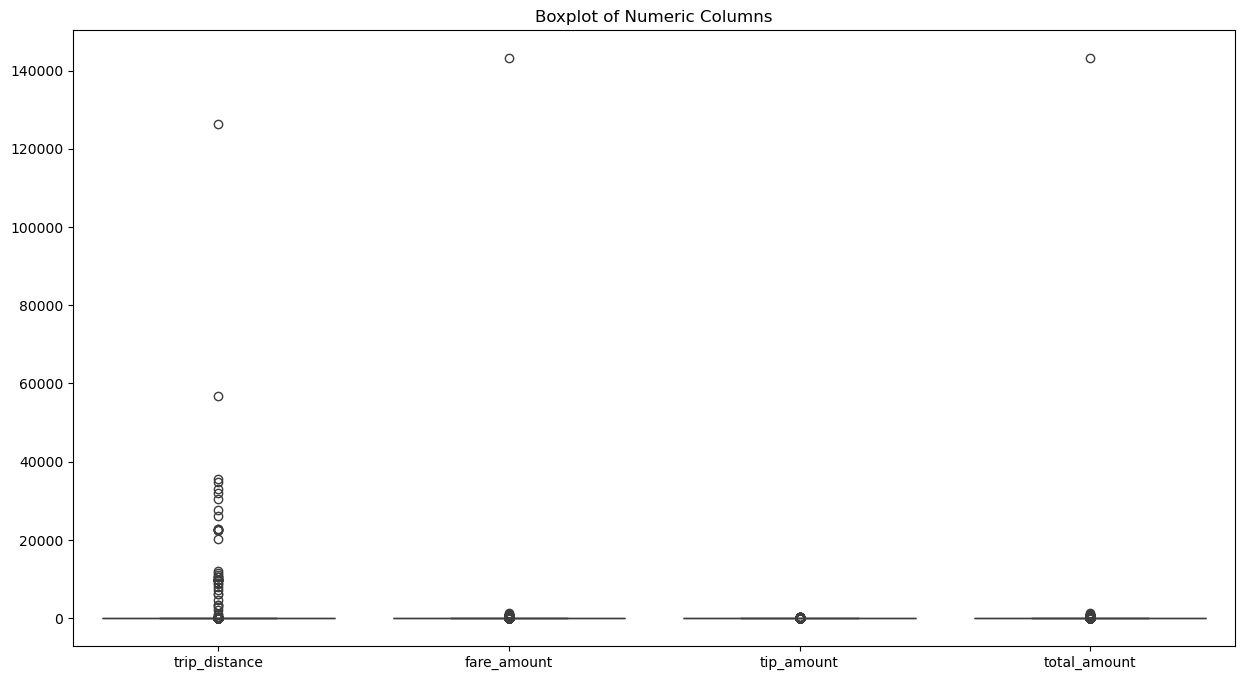

In [56]:
# Describe the data and check if there are any potential outliers present
df.describe()
# Check for potential out of place values in various columns

plt.figure(figsize=(15, 8))
sns.boxplot(data=df[['trip_distance', 'fare_amount', 'tip_amount', 'total_amount']])
plt.title('Boxplot of Numeric Columns')
plt.show()

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [57]:
# remove passenger_count > 6
df = df[df['passenger_count'] <= 6]
df['passenger_count'].max()

6.0

In [60]:
# Continue with outlier handling
def clean_outliers(df):
    # Calculate fare per mile using only valid distances
    valid_trips = df[df['trip_distance'] <= 250]
    fare_per_mile = valid_trips['fare_amount'].sum() / valid_trips['trip_distance'].sum()

    # Add anomaly flags
    df['anomaly_high_fare_low_dist'] = (df['trip_distance'] < 0.1) & (df['fare_amount'] > 300)
    df['anomaly_zero_fare_dist_diff_zone'] = (df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID'])
    df['anomaly_distance_over_250'] = df['trip_distance'] > 250
    df['anomaly_invalid_payment'] = df['payment_type'] == 0

    # Drop entries with high fare and near-zero distance
    df = df[~df['anomaly_high_fare_low_dist']]

    # Drop entries where fare and distance are zero but PU and DO zones differ
    df = df[~df['anomaly_zero_fare_dist_diff_zone']]

    # Fix trip distances over 250 miles by estimating from fare per mile
    df.loc[df['anomaly_distance_over_250'], 'trip_distance'] = \
        df.loc[df['anomaly_distance_over_250'], 'fare_amount'] / fare_per_mile

    # Replace invalid payment_type (0) with NaN, then impute with mode
    df.loc[df['anomaly_invalid_payment'], 'payment_type'] = np.nan
    df['payment_type'].fillna(df['payment_type'].mode()[0], inplace=True)

    return df

In [ ]:
# Do any columns need standardising?



## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [68]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour
count,1896379.00,1896379,1896379,1896379.00,1896379.00,1896379.00,1896379.00,1896379.00,1896379.00,1896379.00,1896379.00,1896379.00,1896379.00,1896379.00,1896379.00,1896379.00,1896379.00,1896379.00,1896379.00
mean,1.73,2023-07-02 19:59:19.028937,2023-07-02 20:16:45.020354,1.36,3.86,1.61,165.28,164.05,1.16,19.92,1.59,0.50,3.55,0.60,1.00,28.98,2.23,0.14,14.27
min,1.00,2022-12-31 23:51:30,2022-12-31 23:56:06,0.00,0.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,2023-04-02 16:09:36,2023-04-02 16:27:32,1.00,1.05,1.00,132.00,114.00,1.00,9.30,0.00,0.50,1.00,0.00,1.00,15.96,2.50,0.00,11.00
50%,2.00,2023-06-27 15:43:31,2023-06-27 16:00:53,1.00,1.79,1.00,162.00,162.00,1.00,13.50,1.00,0.50,2.85,0.00,1.00,21.00,2.50,0.00,15.00
75%,2.00,2023-10-06 19:37:07,2023-10-06 19:53:20.500000,1.00,3.40,1.00,234.00,234.00,1.00,21.90,2.50,0.50,4.42,0.00,1.00,30.94,2.50,0.00,19.00
max,6.00,2023-12-31 23:57:51,2024-01-01 20:50:55,6.00,126360.46,99.00,265.00,265.00,4.00,143163.45,20.80,4.00,223.08,143.00,1.00,143167.45,2.50,1.75,23.00
std,0.45,NaN,NaN,0.88,129.41,7.27,64.00,69.80,0.51,105.54,1.83,0.05,4.05,2.19,0.03,106.42,0.78,0.46,5.81


In [62]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'pickup_date',
 'pickup_hour']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

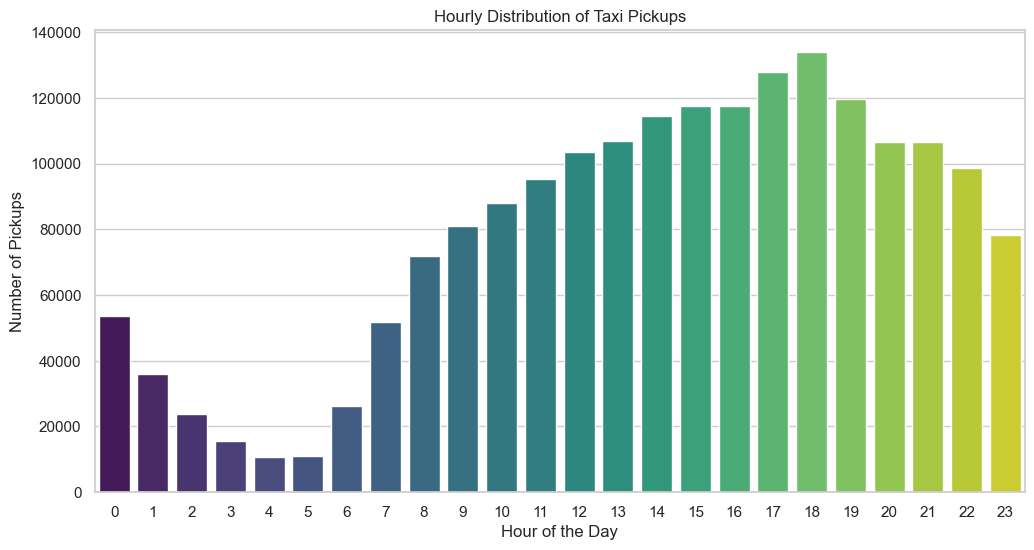

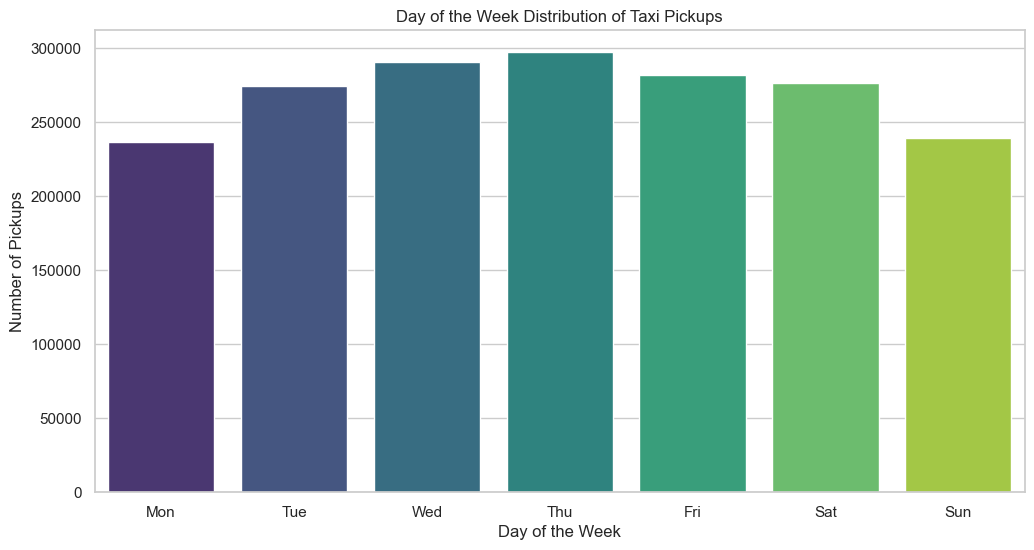

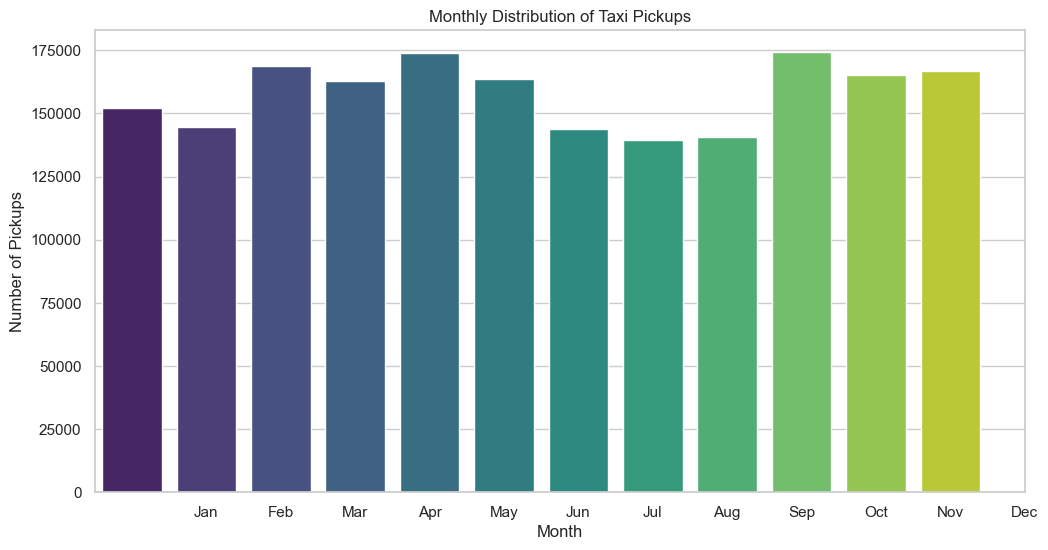

In [70]:
# Find and show the hourly trends in taxi pickups
# Ensure that the datetime column is parsed correctly
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

# Extract additional time features
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.dayofweek  # Monday=0, Sunday=6
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month  # 1=January, 12=December

# 1. Hourly Distribution of Taxi Pickups
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.countplot(x='pickup_hour', data=df, palette='viridis')
plt.title('Hourly Distribution of Taxi Pickups')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Pickups')
plt.xticks(range(0, 24))
plt.show()

# 2. Day of the Week Distribution of Taxi Pickups
plt.figure(figsize=(12, 6))
sns.countplot(x='pickup_day', data=df, palette='viridis')
plt.title('Day of the Week Distribution of Taxi Pickups')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Pickups')
plt.xticks(range(0, 7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.show()

# 3. Monthly Distribution of Taxi Pickups
plt.figure(figsize=(12, 6))
sns.countplot(x='pickup_month', data=df, palette='viridis')
plt.title('Monthly Distribution of Taxi Pickups')
plt.xlabel('Month')
plt.ylabel('Number of Pickups')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

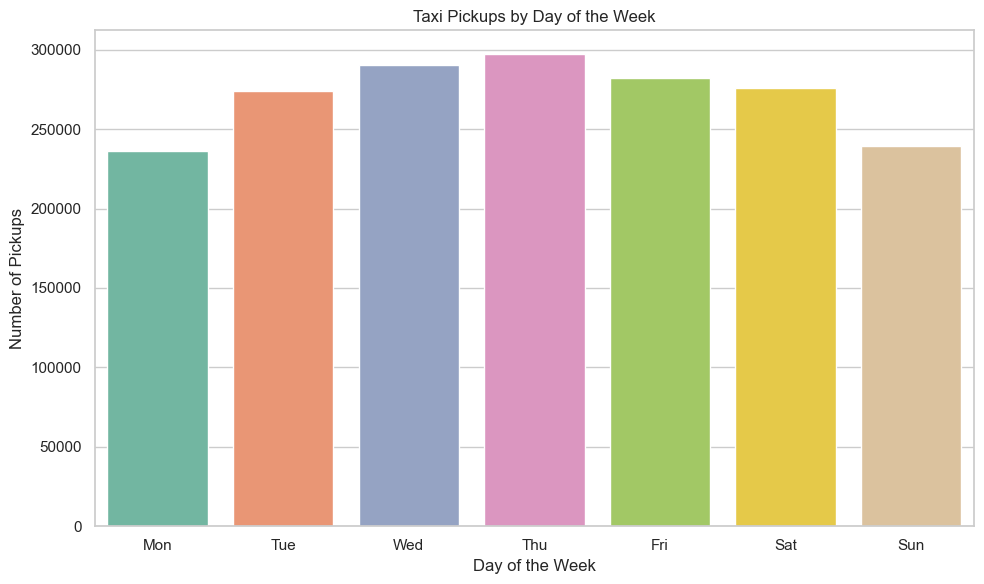

In [73]:
# Find and show the daily trends in taxi pickups (days of the week)
# Ensure datetime type and extract day names directly
df['pickup_day'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.day_name().str[:3]

# Plotting the count of pickups by day of week
plt.figure(figsize=(10, 6))
sns.countplot(
    x='pickup_day',
    data=df,
    order=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
    palette='Set2'
)
plt.title('Taxi Pickups by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Pickups')
plt.tight_layout()
plt.show()


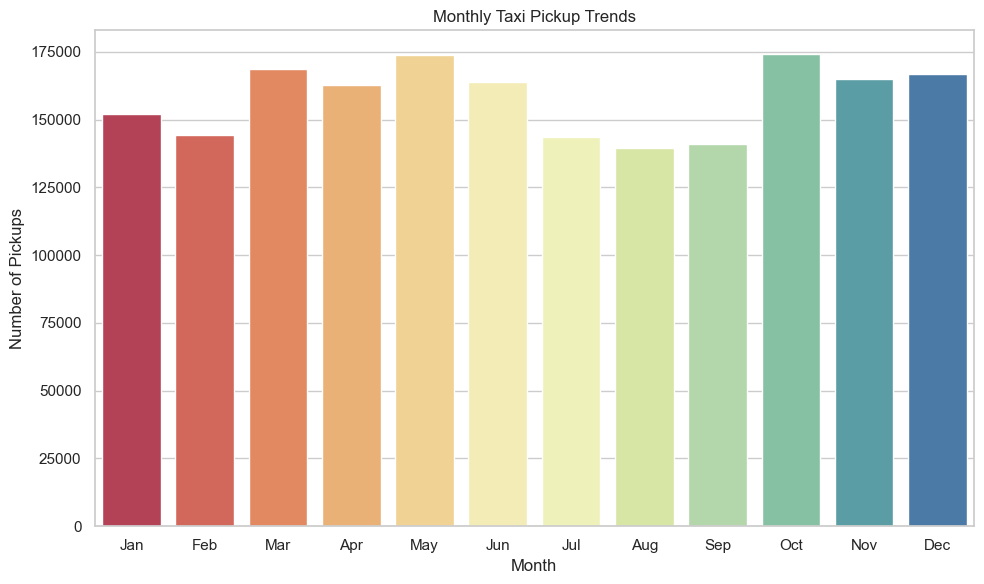

In [75]:
# Show the monthly trends in pickups

# Ensure datetime type and extract 3-letter month name directly
df['pickup_month'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.strftime('%b')

# Define month order for plotting
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Plot monthly trends
plt.figure(figsize=(10, 6))
sns.countplot(x='pickup_month', data=df, order=month_order, palette='Spectral')
plt.title('Monthly Taxi Pickup Trends')
plt.xlabel('Month')
plt.ylabel('Number of Pickups')
plt.tight_layout()
plt.show()


##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [77]:
# Analyse the above parameters

financial_columns = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']
for col in financial_columns:
    zero_vals = (df[col] == 0).sum()
    neg_vals = (df[col] < 0).sum()
    print(f"{col} — Zero values: {zero_vals:,}, Negative values: {neg_vals:,}")

fare_amount — Zero values: 651, Negative values: 0
tip_amount — Zero values: 435,951, Negative values: 0
total_amount — Zero values: 388, Negative values: 0
trip_distance — Zero values: 37,722, Negative values: 0


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [79]:
# Create a df with non zero entries for the selected parameters.

filtered_df = df[(df['fare_amount'] > 0) & 
                 (df['tip_amount'] > 0) & 
                 (df['total_amount'] > 0)]


filtered_df = filtered_df[(filtered_df['trip_distance'] > 0) | 
                          (filtered_df['PULocationID'] == filtered_df['DOLocationID'])]

# Check how much data is retained
print(f"Original DataFrame shape: {df.shape}")
print(f"Filtered DataFrame shape: {filtered_df.shape}")

Original DataFrame shape: (1896379, 23)
Filtered DataFrame shape: (1456727, 23)


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

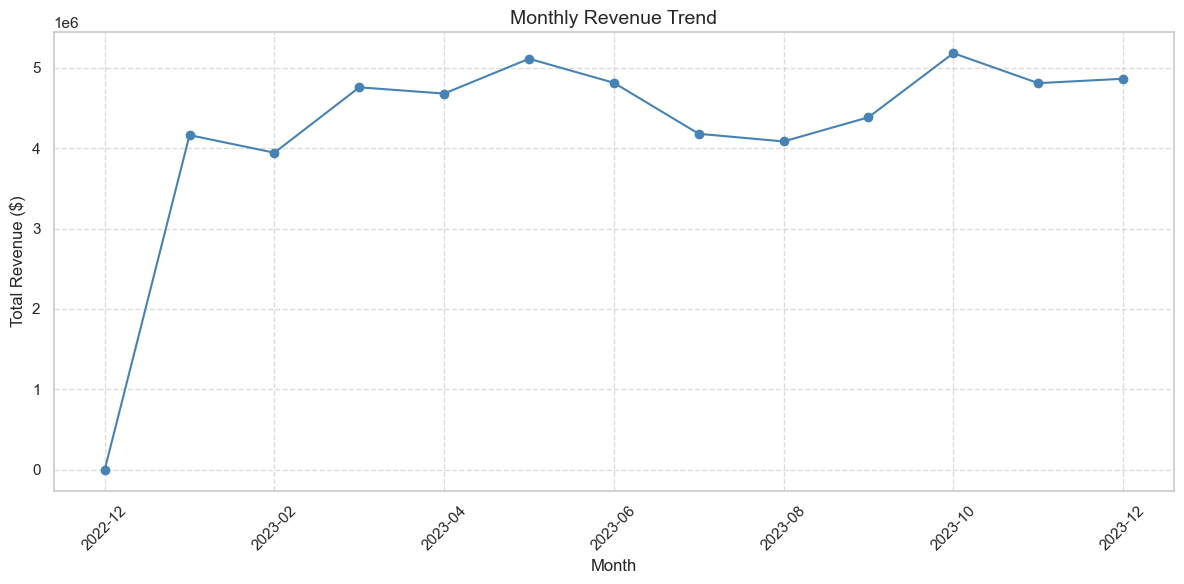

In [81]:
# Group data by month and analyse monthly revenue

# Ensure pickup datetime is in datetime format
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

# Extract 'YYYY-MM' format for grouping
df['pickup_month'] = df['tpep_pickup_datetime'].dt.to_period('M').astype(str)

# Group by month and sum total revenue
monthly_revenue = df.groupby('pickup_month')['total_amount'].sum()

# Plot the trend
plt.figure(figsize=(12, 6))
monthly_revenue.plot(marker='o', linestyle='-', color='steelblue')
plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

Quarterly Revenue Proportion (%):
pickup_quarter
2022Q4    0.00
2023Q1   23.40
2023Q2   26.57
2023Q3   23.01
2023Q4   27.02
Name: total_amount, dtype: float64


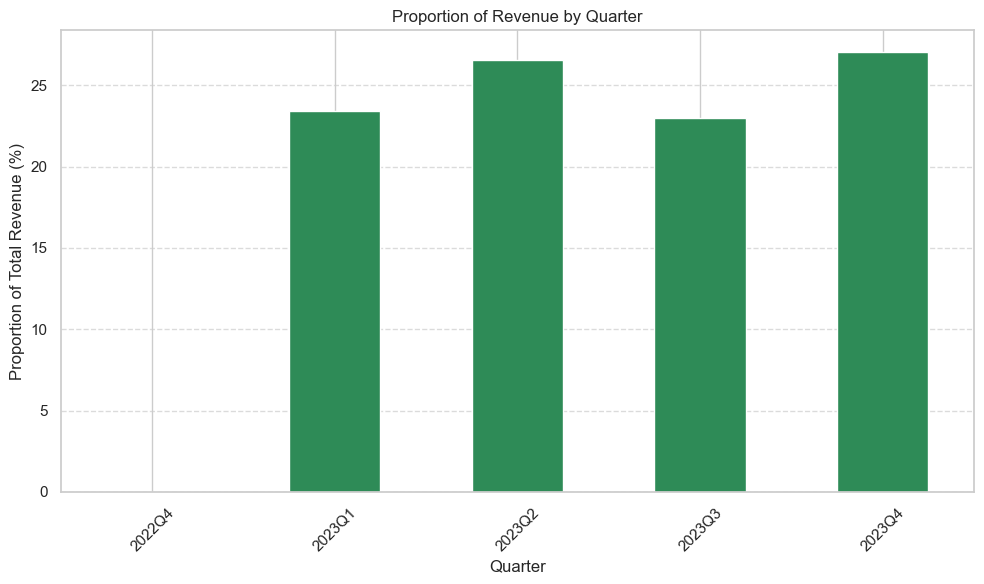

In [83]:
# Calculate proportion of each quarter
# Ensure datetime format
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

# Extract quarter (e.g., '2023Q1') as string for labeling
df['pickup_quarter'] = df['tpep_pickup_datetime'].dt.to_period('Q').astype(str)

# Calculate total revenue per quarter
quarterly_revenue = df.groupby('pickup_quarter')['total_amount'].sum()

# Calculate revenue proportion for each quarter
quarterly_proportion = (quarterly_revenue / quarterly_revenue.sum()) * 100

# Display the proportions
print("Quarterly Revenue Proportion (%):")
print(quarterly_proportion.round(2))

# Plot the proportion
plt.figure(figsize=(10, 6))
quarterly_proportion.plot(kind='bar', color='seagreen')
plt.title('Proportion of Revenue by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Proportion of Total Revenue (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

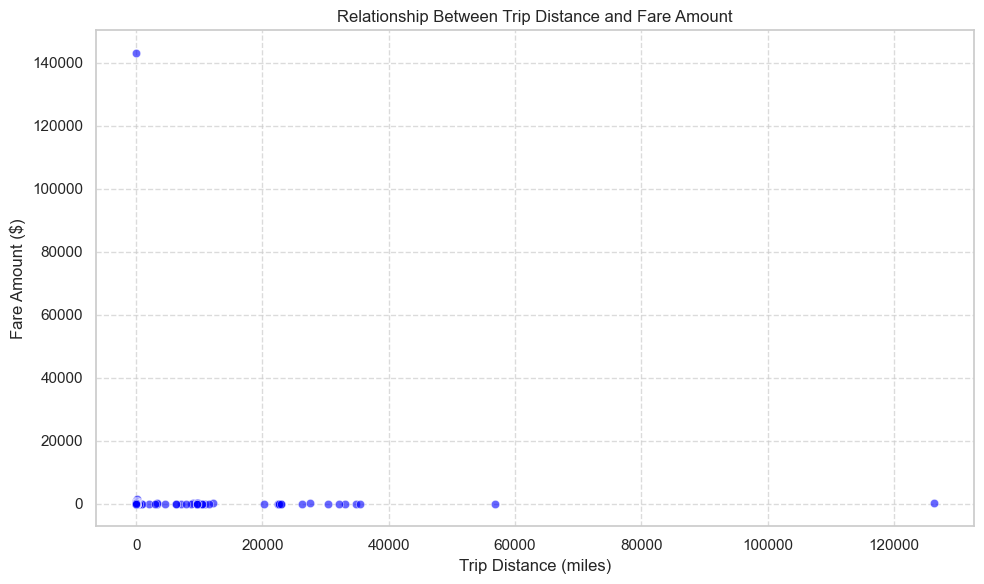

Correlation between trip_distance and fare_amount: 0.0060


In [85]:
# Show how trip fare is affected by distance
# Filter out trips with zero distance
df_filtered = df[df['trip_distance'] > 0]

# Scatter plot to visualize the relationship between trip distance and fare amount
plt.figure(figsize=(10, 6))
sns.scatterplot(x='trip_distance', y='fare_amount', data=df_filtered, color='blue', alpha=0.6)
plt.title('Relationship Between Trip Distance and Fare Amount')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Calculate and print the correlation between trip distance and fare amount
correlation = df_filtered[['trip_distance', 'fare_amount']].corr().iloc[0, 1]
print(f'Correlation between trip_distance and fare_amount: {correlation:.4f}')


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

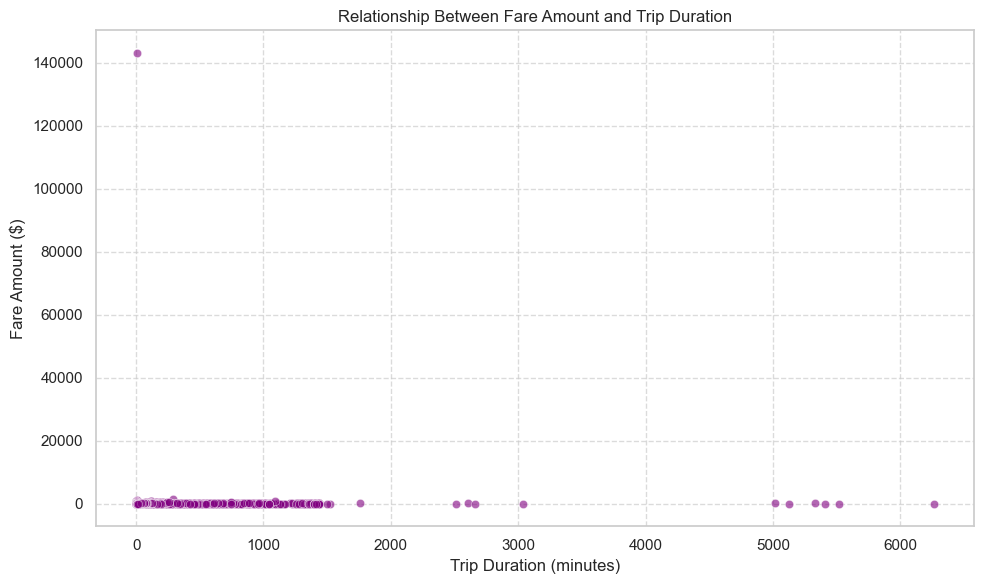

Correlation between fare_amount and trip_duration: 0.0458


In [87]:
# Show relationship between fare and trip duration
# Convert pickup and dropoff datetime columns to datetime format
df['pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Calculate trip duration in minutes
df['trip_duration'] = (df['dropoff_datetime'] - df['pickup_datetime']).dt.total_seconds() / 60

# Filter out rows with zero or negative trip duration
df_filtered = df[df['trip_duration'] > 0]

# Scatter plot for visualizing the relationship between trip duration and fare amount
plt.figure(figsize=(10, 6))
sns.scatterplot(x='trip_duration', y='fare_amount', data=df_filtered, color='purple', alpha=0.6)
plt.title('Relationship Between Fare Amount and Trip Duration')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Calculate and display the correlation between fare amount and trip duration
correlation_fare_duration = df_filtered[['fare_amount', 'trip_duration']].corr().iloc[0, 1]
print(f'Correlation between fare_amount and trip_duration: {correlation_fare_duration:.4f}')


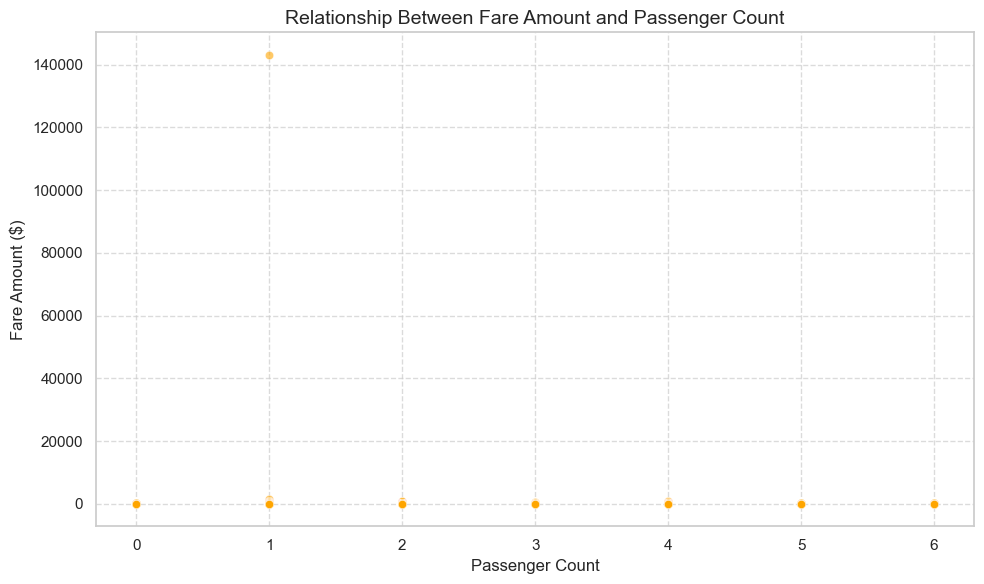

Correlation between fare_amount and passenger_count: 0.0072


In [89]:
# Show relationship between fare and number of passengers

# Scatter plot for visualizing the relationship between passenger count and fare amount
plt.figure(figsize=(10, 6))
sns.scatterplot(x='passenger_count', y='fare_amount', data=df_filtered, color='orange', alpha=0.6)
plt.title('Relationship Between Fare Amount and Passenger Count', fontsize=14)
plt.xlabel('Passenger Count', fontsize=12)
plt.ylabel('Fare Amount ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Calculate and display the correlation between fare amount and passenger count
correlation_fare_passenger = df_filtered[['fare_amount', 'passenger_count']].corr().iloc[0, 1]
print(f'Correlation between fare_amount and passenger_count: {correlation_fare_passenger:.4f}')


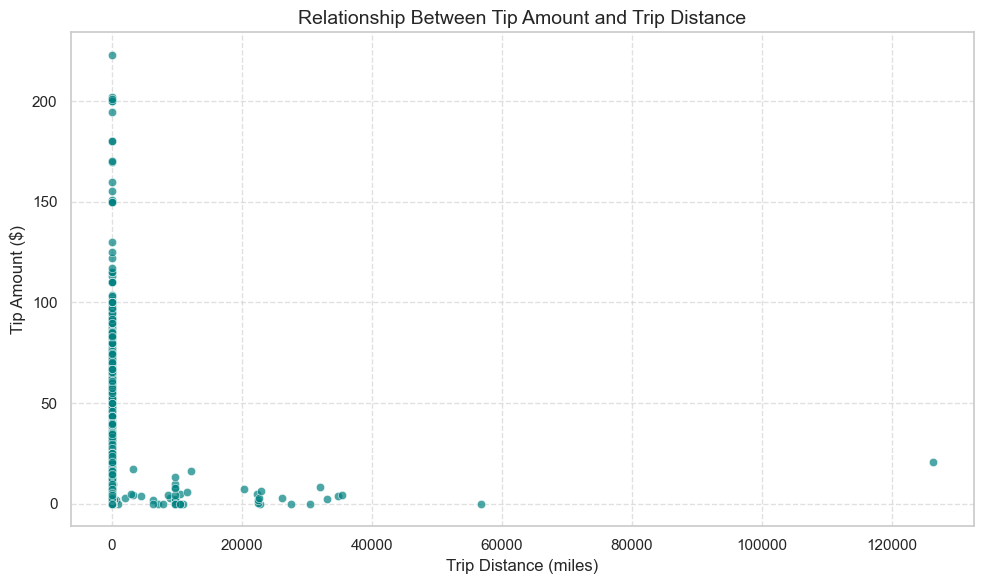

Correlation between tip_amount and trip_distance: 0.0221


In [91]:
# Show relationship between tip and trip distance

# Scatter plot for visualizing the relationship between trip distance and tip amount
plt.figure(figsize=(10, 6))
sns.scatterplot(x='trip_distance', y='tip_amount', data=df_filtered, color='teal', alpha=0.7)
plt.title('Relationship Between Tip Amount and Trip Distance', fontsize=14)
plt.xlabel('Trip Distance (miles)', fontsize=12)
plt.ylabel('Tip Amount ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Calculate and display the correlation between tip amount and trip distance
correlation_tip_distance = df_filtered[['tip_amount', 'trip_distance']].corr().iloc[0, 1]
print(f'Correlation between tip_amount and trip_distance: {correlation_tip_distance:.4f}')


**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

payment_type_desc
Credit card   81.48
Cash          17.28
Dispute        0.75
No charge      0.49
Name: proportion, dtype: float64


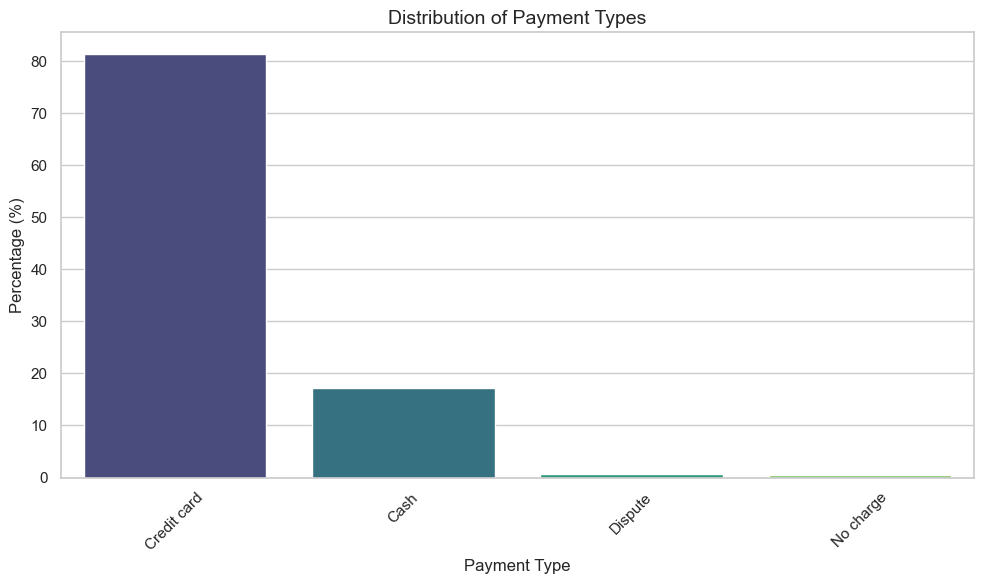

In [93]:
# Analyse the distribution of different payment types (payment_type).

# Map payment type codes to descriptive labels
payment_type_mapping = {
    1: 'Credit card',
    2: 'Cash',
    3: 'No charge',
    4: 'Dispute',
    5: 'Unknown',
    6: 'Voided trip'
}

# Add a new column 'payment_type_desc' with mapped labels
df['payment_type_desc'] = df['payment_type'].map(payment_type_mapping)

# Calculate the percentage distribution of each payment type
payment_counts = df['payment_type_desc'].value_counts(normalize=True) * 100

# Display the distribution
print(payment_counts)

# Plot the distribution of payment types
plt.figure(figsize=(10, 6))
sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='viridis')
plt.title('Distribution of Payment Types', fontsize=14)
plt.xlabel('Payment Type', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [99]:
# !pip install geopandas
!pip install geopandas

Defaulting to user installation because normal site-packages is not writeable


**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [101]:
# import geopandas as gpd
import geopandas as gpd

# Read the shapefile using geopandas
zones = gpd.read_file(r"C:\AI ML Assignments\Datasets and Dictionary-NYC\Datasets and Dictionary\taxi_zones\taxi_zones.shp")# read the .shp file using gpd
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.12,0.00,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.43,0.00,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.08,0.00,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.04,0.00,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.09,0.00,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

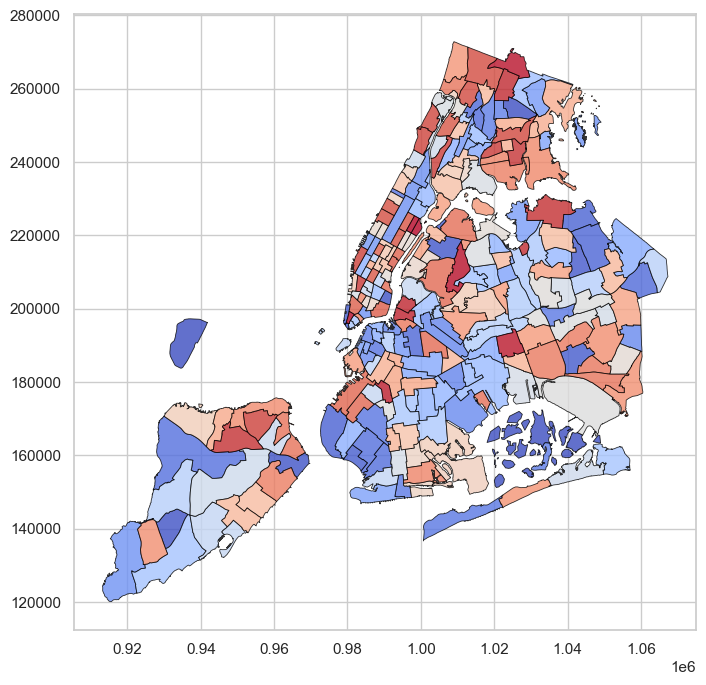

In [105]:
# print(zones.info())
print(zones.info())
# zones.plot()
zones.plot(figsize=(12, 8), edgecolor='black', cmap="coolwarm", alpha=0.8, linewidth=0.6)

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [107]:
# Merge zones and trip records using locationID and PULocationID

# Load the trip records and zones shapefile
df = pd.read_parquet(r"C:\AI ML Assignments\Datasets and Dictionary-NYC\Datasets and Dictionary\trip_records\NYC_Yellow_Taxi_2023_Sample_300K_New_File.parquet")
zones = gpd.read_file(r"C:\AI ML Assignments\Datasets and Dictionary-NYC\Datasets and Dictionary\taxi_zones\taxi_zones.shp")

# Merge the trip data with the zone data on PULocationID and LocationID
df_merged = df.merge(
    zones[['LocationID', 'zone', 'borough', 'geometry']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

# Renaming the columns for better clarity
df_merged.rename(columns={
    'zone': 'pickup_zone',
    'borough': 'pickup_borough'
}, inplace=True)

# Drop the redundant LocationID column after merging
df_merged.drop(columns=['LocationID'], inplace=True)

# Optionally, you can check the result of the merge
print(df_merged.head())


   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         2  2023-01-01 00:07:18   2023-01-01 00:23:15             1.00   
1         2  2023-01-01 00:16:41   2023-01-01 00:21:46             2.00   
2         2  2023-01-01 00:14:03   2023-01-01 00:24:36             3.00   
3         2  2023-01-01 00:24:30   2023-01-01 00:29:55             1.00   
4         2  2023-01-01 00:43:00   2023-01-01 01:01:00              NaN   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0           7.74        1.00                  N           138           256   
1           1.24        1.00                  N           161           237   
2           1.44        1.00                  N           237           141   
3           0.54        1.00                  N           143           142   
4          19.24         NaN               None            66           107   

   payment_type  ...  improvement_surcharge  total_amount  \
0            

**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [109]:
# Group data by location and calculate the number of trips
pickup_counts = df.groupby('PULocationID').size().reset_index(name='pickup_trip_count').sort_values('pickup_trip_count', ascending=False)
dropoff_counts = df.groupby('DOLocationID').size().reset_index(name='dropoff_trip_count').sort_values('dropoff_trip_count', ascending=False)

# Optionally, display the first few rows of the results
print("Pickup Counts:")
print(pickup_counts.head())

print("\nDropoff Counts:")
print(dropoff_counts.head())


Pickup Counts:
     PULocationID  pickup_trip_count
125           132              97047
229           237              88610
154           161              87590
228           236              79756
155           162              66712

Dropoff Counts:
     DOLocationID  dropoff_trip_count
230           236               83444
231           237               79428
156           161               73729
224           230               57965
165           170               55798


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [111]:
# Merge trip counts back to the zones GeoDataFrame
zones_with_pickups = zones.merge(
    pickup_counts,
    left_on='LocationID',
    right_on='PULocationID',
    how='left'
)
zones_with_pickups['pickup_trip_count'] = zones_with_pickups['pickup_trip_count'].fillna(0).astype(int)

# Merge dropoff trip counts with zones
zones_with_dropoffs = zones.merge(
    dropoff_counts,
    left_on='LocationID',
    right_on='DOLocationID',
    how='left'
)
zones_with_dropoffs['dropoff_trip_count'] = zones_with_dropoffs['dropoff_trip_count'].fillna(0).astype(int)

# Optional: View the first few rows of the merged results
print("Zones with Pickups:")
print(zones_with_pickups[['LocationID', 'pickup_trip_count']].head())

print("\nZones with Dropoffs:")
print(zones_with_dropoffs[['LocationID', 'dropoff_trip_count']].head())




Zones with Pickups:
   LocationID  pickup_trip_count
0           1                218
1           2                  2
2           3                 44
3           4               2356
4           5                 13

Zones with Dropoffs:
   LocationID  dropoff_trip_count
0           1                5744
1           2                   4
2           3                 157
3           4                7205
4           5                  33


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

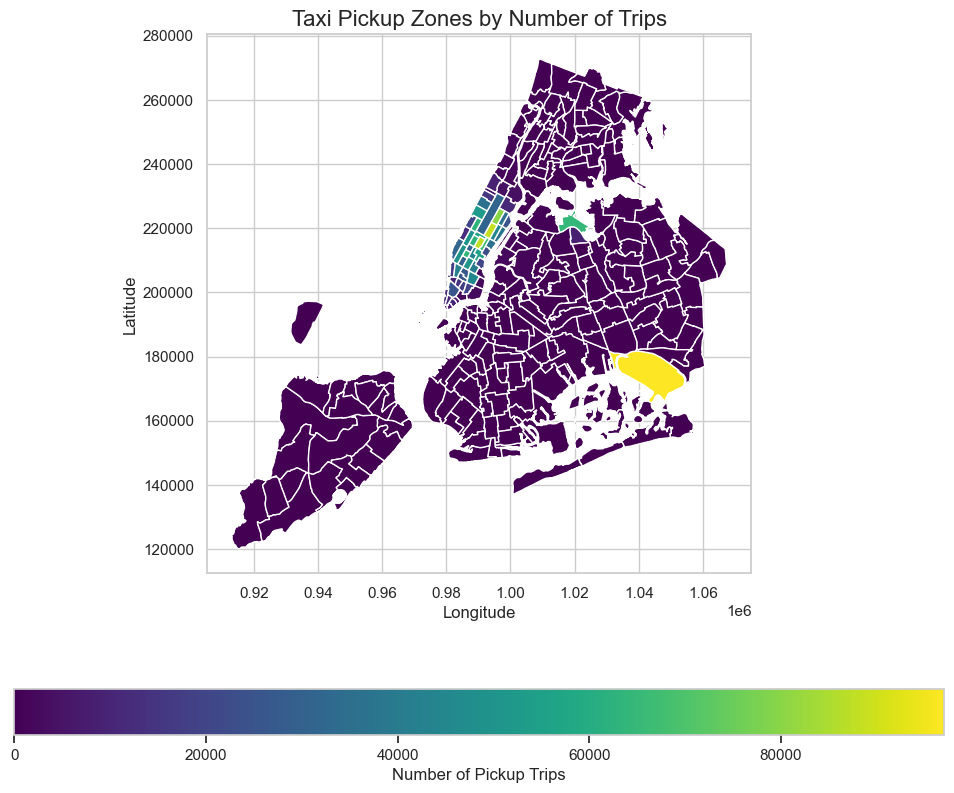

In [113]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the map and display it

zones_with_pickups.plot(
    column='pickup_trip_count', 
    ax=ax, 
    legend=True,
    legend_kwds={
        'label': "Number of Pickup Trips", 
        'orientation': 'horizontal'
    },
    cmap='viridis'  # Optional: Choose a color map for better aesthetics
)

# Set title for the plot
plt.title("Taxi Pickup Zones by Number of Trips", fontsize=16)

# Optional: Customize axis labels
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)

# Show the plot
plt.show()

In [115]:
# can you try displaying the zones DF sorted by the number of trips?

# Sort the zones DataFrame by the number of pickup trips in descending order
sorted_zones = zones_with_pickups.sort_values(by='pickup_trip_count', ascending=False)

# Display the top 10 zones with the most pickup trips
top_10_zones = sorted_zones[['zone', 'pickup_trip_count']].head(10)

# Print the result
print(top_10_zones)

                             zone  pickup_trip_count
131                   JFK Airport              97047
236         Upper East Side South              88610
160                Midtown Center              87590
235         Upper East Side North              79756
161                  Midtown East              66712
137             LaGuardia Airport              64449
185  Penn Station/Madison Sq West              64318
229     Times Sq/Theatre District              62672
141           Lincoln Square East              62664
169                   Murray Hill              55933


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [117]:
# Find routes which have the slowest speeds at different times of the day
# Ensure that 'tpep_pickup_datetime' and 'tpep_dropoff_datetime' are datetime objects
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Calculate trip duration in seconds and add as a new column
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds()

# Check the columns in the DataFrame to ensure all required ones are present
print("Columns in DataFrame:", df.columns)

# Check for missing values in critical columns before proceeding
missing_values = df[['trip_distance', 'trip_duration', 'pickup_hour', 'PULocationID', 'DOLocationID']].isnull().sum()
print("Missing values in relevant columns:\n", missing_values)

# Data cleaning: Filter out trips with a duration <= 30 seconds or negative/zero trip distance
df_clean = df[(df['trip_duration'] > 30) & (df['trip_distance'] > 0)]

# Ensure there are no NaN values after cleaning
print("Missing values after cleaning:\n", df_clean[['trip_distance', 'trip_duration', 'pickup_hour', 'PULocationID', 'DOLocationID']].isnull().sum())

# Group by pickup hour and locations, then aggregate trip distance and duration
route_stats = df_clean.groupby(['pickup_hour', 'PULocationID', 'DOLocationID']).agg({
    'trip_distance': 'sum',
    'trip_duration': 'sum'
}).reset_index()

# Calculate speed for each route (in miles per hour)
route_stats['speed'] = route_stats['trip_distance'] / (route_stats['trip_duration'] / 3600)

# Remove rows with non-positive speeds (to avoid calculation errors)
route_stats = route_stats[route_stats['speed'] > 0]

# Display the 20 slowest routes based on speed
slowest_routes = route_stats.sort_values(by='speed').head(20)
print("Slowest Routes (Top 20):\n", slowest_routes)



Columns in DataFrame: Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee', 'pickup_date',
       'pickup_hour', 'Airport_fee', 'trip_duration'],
      dtype='object')
Missing values in relevant columns:
 trip_distance    0
trip_duration    0
pickup_hour      0
PULocationID     0
DOLocationID     0
dtype: int64
Missing values after cleaning:
 trip_distance    0
trip_duration    0
pickup_hour      0
PULocationID     0
DOLocationID     0
dtype: int64
Slowest Routes (Top 20):
         pickup_hour  PULocationID  DOLocationID  trip_distance  trip_duration  \
68127            13           232            65           0.49      331346.00   
94040            17           243           264     

How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

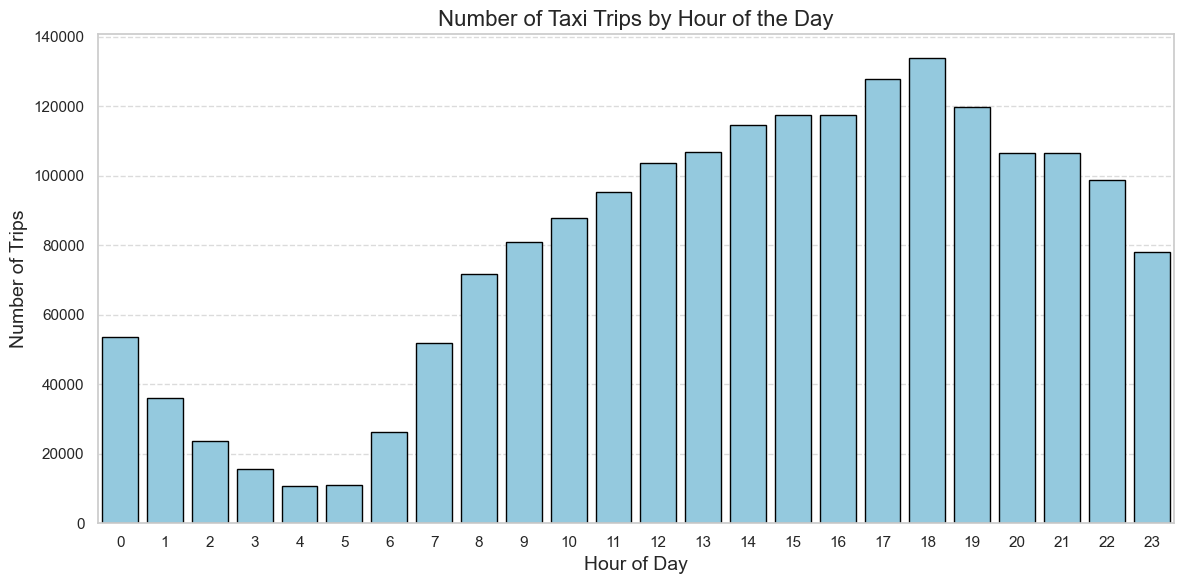

busiest hour: 18:00 with 133,938 trips.


In [119]:
# Visualise the number of trips per hour and find the busiest hour
# Calculate the number of trips per hour
hourly_counts = df.groupby('pickup_hour').size().sort_index()

# Plot the number of trips by hour
plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_counts.index, y=hourly_counts.values, color='skyblue', edgecolor='black')

# Customize the plot
plt.title('Number of Taxi Trips by Hour of the Day', fontsize=16)
plt.xlabel('Hour of Day', fontsize=14)
plt.ylabel('Number of Trips', fontsize=14)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()

# Identify the busiest hour
busiest_hour = hourly_counts.idxmax()
num_trips_busiest_hour = hourly_counts.max()

# Display the busiest hour with formatted output
print(f"busiest hour: {busiest_hour}:00 with {num_trips_busiest_hour:,} trips.")



Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [121]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 300000 / 36500000  # ≈ 0.00822

# Get the top 5 busiest hours
top5_hours = hourly_counts.sort_values(ascending=False).head(5)

# Scale up the counts
top5_scaled = (top5_hours / sample_fraction).astype(int)

# Show results
print("Actual estimated number of trips during the 5 busiest hours:")
print(top5_scaled)


Actual estimated number of trips during the 5 busiest hours:
pickup_hour
18    16295790
17    15557151
19    14558876
16    14297293
15    14284518
dtype: int32


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

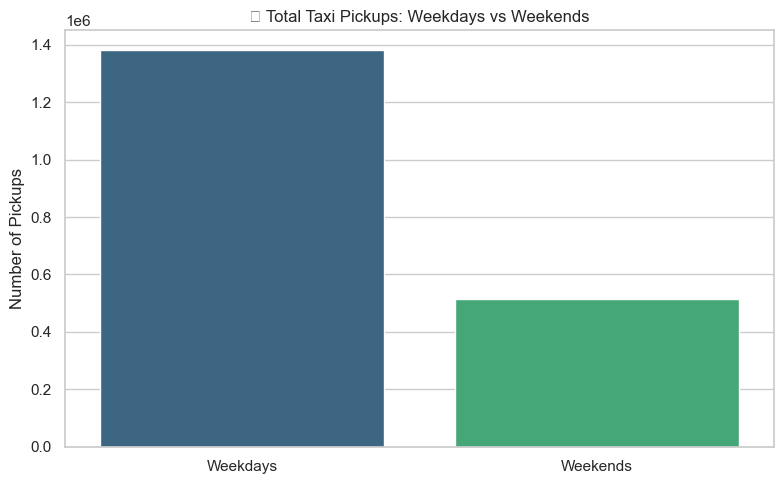

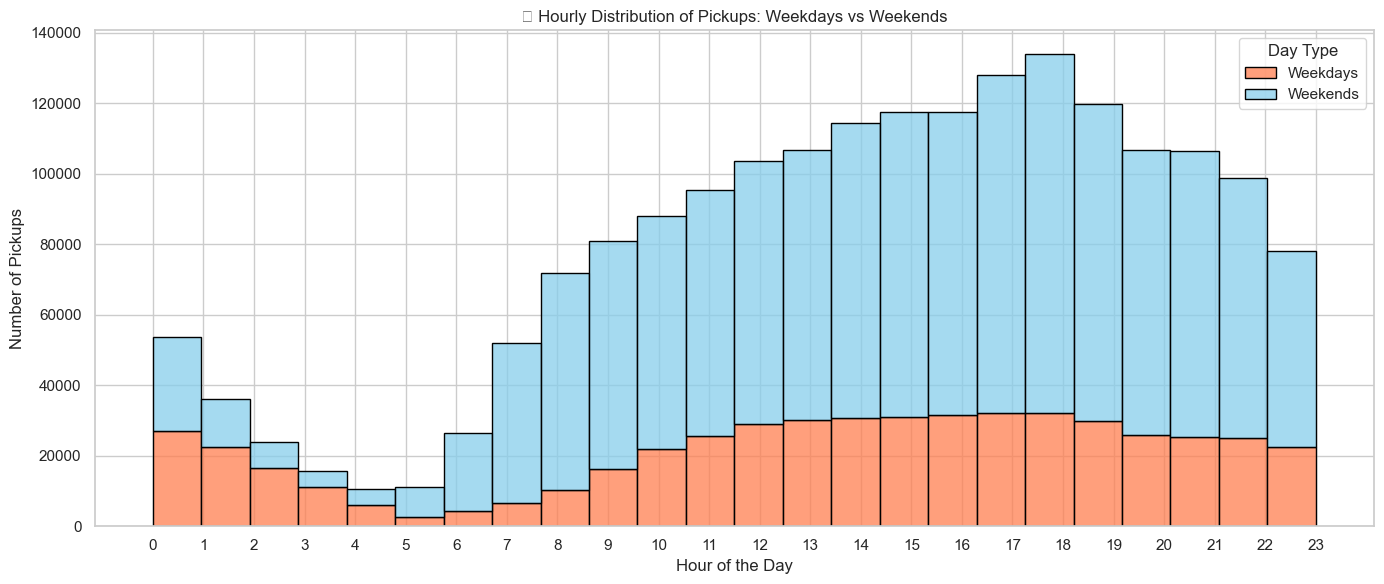

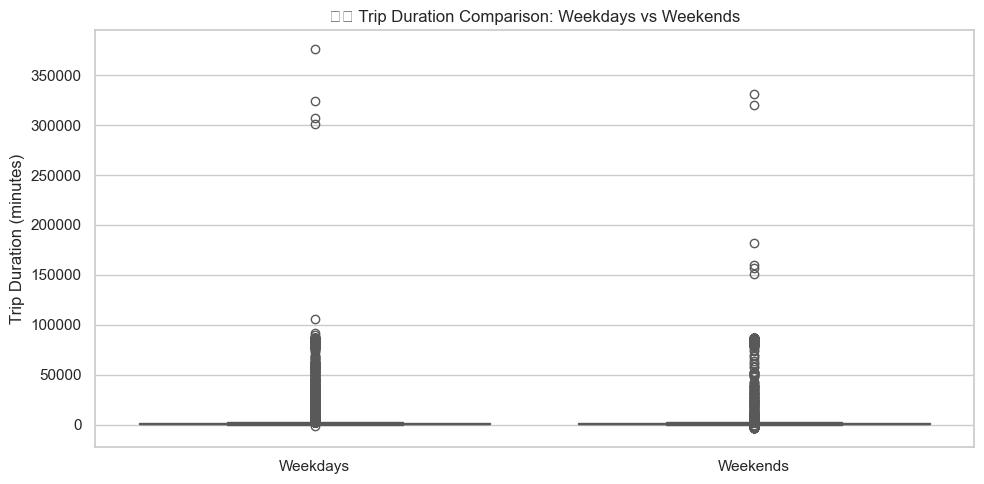

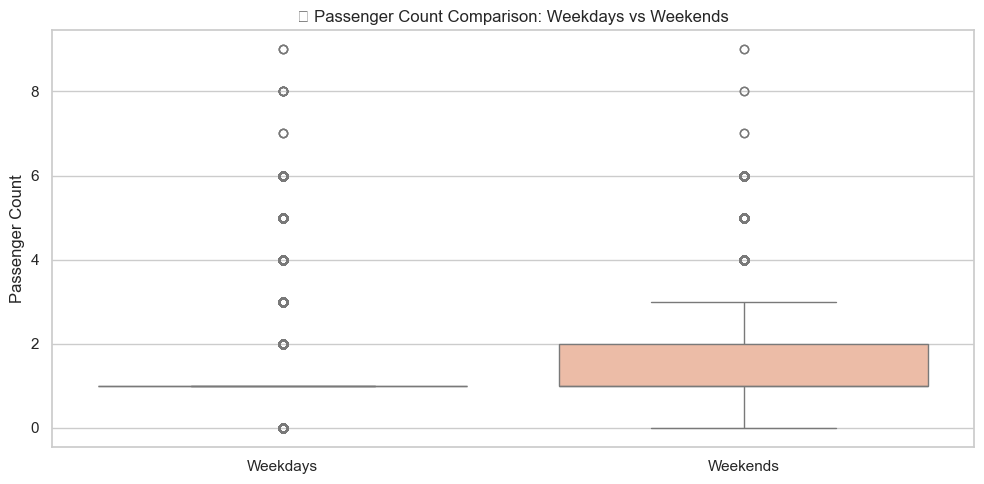

In [127]:
# Compare traffic trends for the week days and weekends

# Ensure datetime format
df['pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

# Derive time-based features
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['is_weekend'] = df['day_of_week'] >= 5  # Saturday = 5, Sunday = 6

# ------------------------------
# 1. Pickup Counts: Weekday vs Weekend
# ------------------------------
plt.figure(figsize=(8, 5))
sns.countplot(x='is_weekend', data=df, palette='viridis')
plt.title('📊 Total Taxi Pickups: Weekdays vs Weekends')
plt.xlabel('')
plt.ylabel('Number of Pickups')
plt.xticks([0, 1], ['Weekdays', 'Weekends'])
plt.tight_layout()
plt.show()

# ------------------------------
# 2. Hourly Distribution: Weekdays vs Weekends
# ------------------------------
plt.figure(figsize=(14, 6))
sns.histplot(data=df, x='pickup_hour', hue='is_weekend', multiple='stack',
             palette={False: 'skyblue', True: 'coral'}, bins=24, edgecolor='black')
plt.title('🕒 Hourly Distribution of Pickups: Weekdays vs Weekends')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Pickups')
plt.xticks(range(0, 24))
plt.legend(labels=['Weekdays', 'Weekends'], title='Day Type')
plt.tight_layout()
plt.show()

# ------------------------------
# 3. Trip Duration Comparison
# ------------------------------
plt.figure(figsize=(10, 5))
sns.boxplot(x='is_weekend', y='trip_duration', data=df, palette='Set2')
plt.title('⏱️ Trip Duration Comparison: Weekdays vs Weekends')
plt.xlabel('')
plt.ylabel('Trip Duration (minutes)')
plt.xticks([0, 1], ['Weekdays', 'Weekends'])
plt.tight_layout()
plt.show()

# ------------------------------
# 4. Passenger Count Comparison
# ------------------------------
plt.figure(figsize=(10, 5))
sns.boxplot(x='is_weekend', y='passenger_count', data=df, palette='coolwarm')
plt.title('🧍 Passenger Count Comparison: Weekdays vs Weekends')
plt.xlabel('')
plt.ylabel('Passenger Count')
plt.xticks([0, 1], ['Weekdays', 'Weekends'])
plt.tight_layout()
plt.show()


What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [129]:
# Find top 10 pickup and dropoff zones

# Calculate Top 10 Pickup and Dropoff Zones
pickup_counts = df['PULocationID'].value_counts().head(10).reset_index()
pickup_counts.columns = ['LocationID', 'pickup_count']

dropoff_counts = df['DOLocationID'].value_counts().head(10).reset_index()
dropoff_counts.columns = ['LocationID', 'dropoff_count']

# Optional: Merge with zone names if 'zones' GeoDataFrame is available
if 'zones' in globals():
    pickup_counts = pickup_counts.merge(zones[['LocationID', 'zone']], on='LocationID', how='left')
    dropoff_counts = dropoff_counts.merge(zones[['LocationID', 'zone']], on='LocationID', how='left')

# Display results
print("Top 10 Pickup Zones:")
print(pickup_counts[['zone', 'pickup_count']] if 'zone' in pickup_counts else pickup_counts)

print("\n Top 10 Dropoff Zones:")
print(dropoff_counts[['zone', 'dropoff_count']] if 'zone' in dropoff_counts else dropoff_counts)


Top 10 Pickup Zones:
                           zone  pickup_count
0                   JFK Airport         97047
1         Upper East Side South         88610
2                Midtown Center         87590
3         Upper East Side North         79756
4                  Midtown East         66712
5             LaGuardia Airport         64449
6  Penn Station/Madison Sq West         64318
7     Times Sq/Theatre District         62672
8           Lincoln Square East         62664
9                   Murray Hill         55933

 Top 10 Dropoff Zones:
                        zone  dropoff_count
0      Upper East Side North          83444
1      Upper East Side South          79428
2             Midtown Center          73729
3  Times Sq/Theatre District          57965
4                Murray Hill          55798
5               Midtown East          53701
6        Lincoln Square East          53043
7      Upper West Side South          52915
8            Lenox Hill West          49859
9        

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

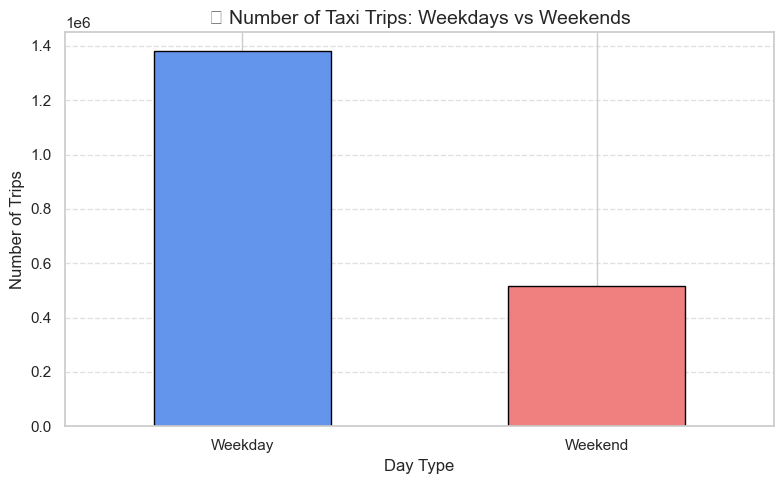

In [131]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

# Derive day of week and classify as weekday/weekend
df['pickup_day'] = df['tpep_pickup_datetime'].dt.dayofweek  # Monday = 0, Sunday = 6
df['day_type'] = df['pickup_day'].map(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# Count trips by day type
trip_counts_by_day_type = df['day_type'].value_counts().reindex(['Weekday', 'Weekend'])

# Plot the distribution
plt.figure(figsize=(8, 5))
trip_counts_by_day_type.plot(kind='bar', color=['cornflowerblue', 'lightcoral'], edgecolor='black')

plt.title('Number of Taxi Trips: Weekdays vs Weekends', fontsize=14)
plt.ylabel('Number of Trips')
plt.xlabel('Day Type')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [135]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

# Define night hours
night_hours = list(range(23, 24)) + list(range(0, 6))  # 11 PM to 5 AM

# Ensure pickup_hour exists and is in integer format
df['pickup_hour'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.hour

# Filter for night-time trips
df_night = df[df['pickup_hour'].isin(night_hours)]

# Function to get top N zones for pickup or dropoff during night hours
def get_top_n_zones(df_subset, location_col, zone_data, top_n=10, label='pickup'):
    top_zones = (
        df_subset.groupby(location_col)
        .size()
        .reset_index(name=f'{label}_count')
        .sort_values(by=f'{label}_count', ascending=False)
        .head(top_n)
        .merge(zone_data[['LocationID', 'zone']], left_on=location_col, right_on='LocationID', how='left')
        [['zone', f'{label}_count']]
    )
    return top_zones

# Get top night pickup and dropoff zones
top_night_pickups = get_top_n_zones(df_night, 'PULocationID', zones, top_n=10, label='pickup')
top_night_dropoffs = get_top_n_zones(df_night, 'DOLocationID', zones, top_n=10, label='dropoff')

# Display the results
print("Top 10 Nighttime Pickup Zones")
print(top_night_pickups)

print("\n Top 10 Nighttime Dropoff Zones")
print(top_night_dropoffs)



Top 10 Nighttime Pickup Zones
                           zone  pickup_count
0                  East Village         16466
1                   JFK Airport         14584
2                  West Village         13144
3                  Clinton East         10834
4               Lower East Side         10191
5       Greenwich Village South          9193
6     Times Sq/Theatre District          8500
7  Penn Station/Madison Sq West          7135
8                 Midtown South          6468
9                  East Chelsea          6402

 Top 10 Nighttime Dropoff Zones
                        zone  dropoff_count
0               East Village           8714
1               Clinton East           7220
2                Murray Hill           6502
3               East Chelsea           6132
4                   Gramercy           5946
5            Lenox Hill West           5546
6             Yorkville West           5279
7               West Village           5128
8  Times Sq/Theatre District       

Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [137]:
# Filter for night hours (11 PM to 5 AM)

# Ensure datetime column is parsed
df['pickup_hour'] = pd.to_datetime(df['pickup_datetime']).dt.hour

# Categorize each trip as 'Night' or 'Day'
df['time_period'] = np.where(df['pickup_hour'].isin([23, 0, 1, 2, 3, 4, 5]), 'Night', 'Day')

# Group by time period and calculate fare revenue
revenue_by_period = df.groupby('time_period')['fare_amount'].sum()

# Calculate total revenue and share
total_revenue = revenue_by_period.sum()
revenue_share_pct = (revenue_by_period / total_revenue * 100).round(2)

# Display results
print("Revenue Share by Time of Day:")
for period in ['Night', 'Day']:
    revenue = revenue_by_period.get(period, 0)
    share = revenue_share_pct.get(period, 0)
    print(f"🔹 {period} Revenue: ${revenue:,.2f} ({share:.2f}%)")


Revenue Share by Time of Day:
🔹 Night Revenue: $4,691,394.81 (12.42%)
🔹 Day Revenue: $33,083,661.37 (87.58%)


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [139]:
# Analyse the fare per mile per passenger for different passenger counts
# Exclude trips with zero distance or zero passengers to avoid invalid calculations
df_valid = df[(df['trip_distance'] > 0) & (df['passenger_count'] > 0)].copy()

# Compute fare per mile and fare per mile per passenger
df_valid['fare_per_mile'] = df_valid['fare_amount'] / df_valid['trip_distance']
df_valid['fare_per_mile_per_passenger'] = df_valid['fare_per_mile'] / df_valid['passenger_count']

# Group by passenger count and compute average fare per mile per passenger
fare_stats = (
    df_valid.groupby('passenger_count')['fare_per_mile_per_passenger']
    .mean()
    .round(2)
    .rename("Avg Fare/Mile/Passenger")
)

# Display results
print("Average Fare per Mile per Passenger by Passenger Count:\n")
print(fare_stats.to_string())

Average Fare per Mile per Passenger by Passenger Count:

passenger_count
1.00   11.06
2.00    6.43
3.00    3.91
4.00    4.43
5.00    1.71
6.00    1.35
7.00    1.31
8.00   28.63
9.00   76.10


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

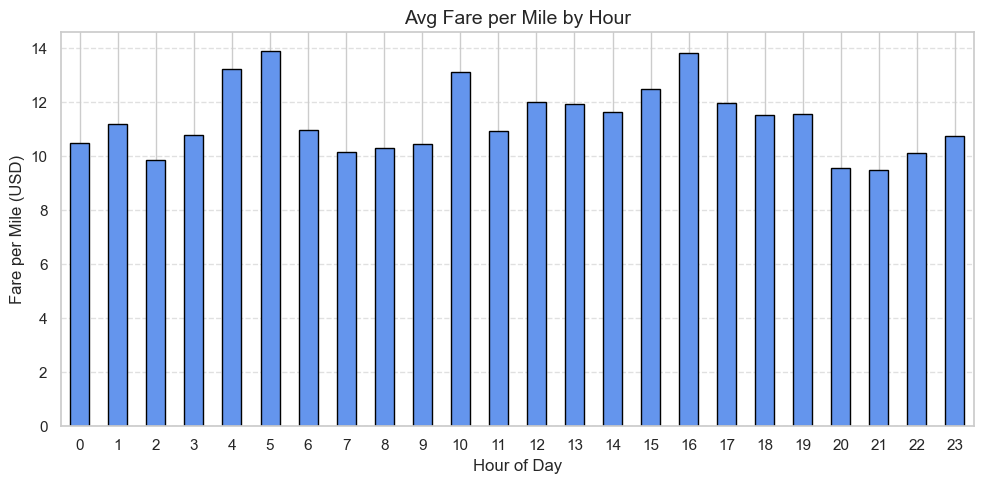

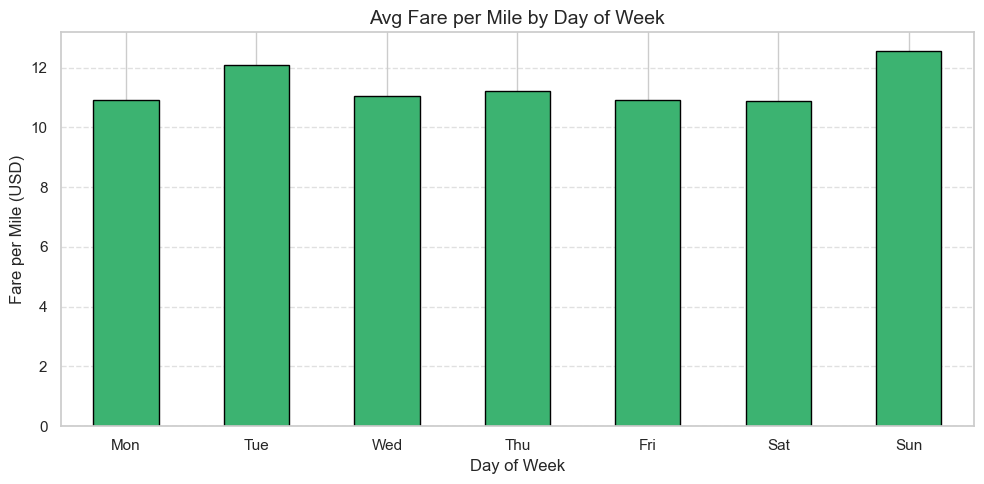

Average Fare per Mile by Hour:
pickup_hour
0    10.47
1    11.20
2     9.87
3    10.80
4    13.23
5    13.89
6    10.98
7    10.15
8    10.31
9    10.46
10   13.10
11   10.94
12   11.99
13   11.94
14   11.63
15   12.50
16   13.81
17   11.97
18   11.54
19   11.56
20    9.56
21    9.48
22   10.12
23   10.73

 Average Fare per Mile by Day of the Week:
pickup_day
0   10.93
1   12.08
2   11.05
3   11.23
4   10.91
5   10.87
6   12.55


In [141]:
# Compare the average fare per mile for different days and for different times of the day

# Filter out trips with zero or negative distance
df_valid = df[df['trip_distance'] > 0].copy()

# Calculate fare per mile
df_valid['fare_per_mile'] = df_valid['fare_amount'] / df_valid['trip_distance']

# Extract pickup hour and day of the week
df_valid['pickup_hour'] = df_valid['pickup_datetime'].dt.hour
df_valid['pickup_day'] = df_valid['pickup_datetime'].dt.dayofweek  # Monday=0, Sunday=6

# Compute average fare per mile by hour and by day
avg_fare_by_hour = df_valid.groupby('pickup_hour')['fare_per_mile'].mean().round(2)
avg_fare_by_day = df_valid.groupby('pickup_day')['fare_per_mile'].mean().round(2)

# Plot: Average fare per mile by hour
plt.figure(figsize=(10, 5))
avg_fare_by_hour.plot(kind='bar', color='cornflowerblue', edgecolor='black')
plt.title("Avg Fare per Mile by Hour", fontsize=14)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Fare per Mile (USD)", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Plot: Average fare per mile by day of the week
plt.figure(figsize=(10, 5))
avg_fare_by_day.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title("Avg Fare per Mile by Day of Week", fontsize=14)
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Fare per Mile (USD)", fontsize=12)
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Print data summary
print("Average Fare per Mile by Hour:")
print(avg_fare_by_hour.to_string())

print("\n Average Fare per Mile by Day of the Week:")
print(avg_fare_by_day.to_string())



**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

<Figure size 1400x600 with 0 Axes>

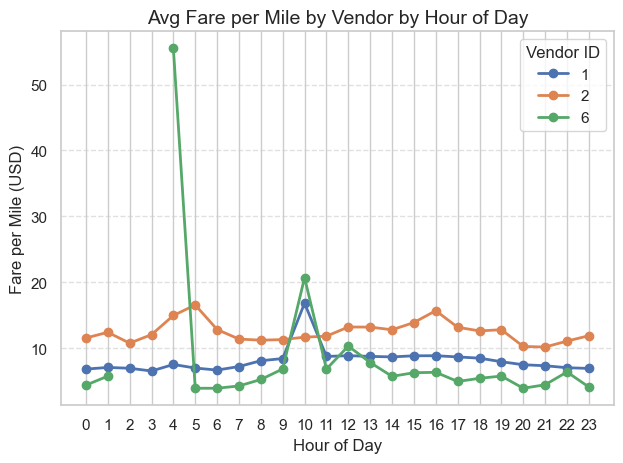

In [143]:
# Compare fare per mile for different vendors

# Filter out invalid or zero values to ensure clean data
df_valid = df[(df['trip_distance'] > 0) & (df['fare_amount'] > 0)].copy()

# Calculate fare per mile
df_valid['fare_per_mile'] = df_valid['fare_amount'] / df_valid['trip_distance']

# Ensure 'pickup_hour' exists
df_valid['pickup_hour'] = df_valid['pickup_datetime'].dt.hour

# Compute average fare per mile grouped by Vendor and Hour
avg_fare_by_vendor_hour = (
    df_valid.groupby(['VendorID', 'pickup_hour'])['fare_per_mile']
    .mean()
    .unstack(level=0)
    .round(2)
)

# Plotting
plt.figure(figsize=(14, 6))
avg_fare_by_vendor_hour.plot(marker='o', linewidth=2)
plt.title("Avg Fare per Mile by Vendor by Hour of Day", fontsize=14)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Fare per Mile (USD)", fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Vendor ID')
plt.tight_layout()
plt.show()


**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


<Figure size 1200x600 with 0 Axes>

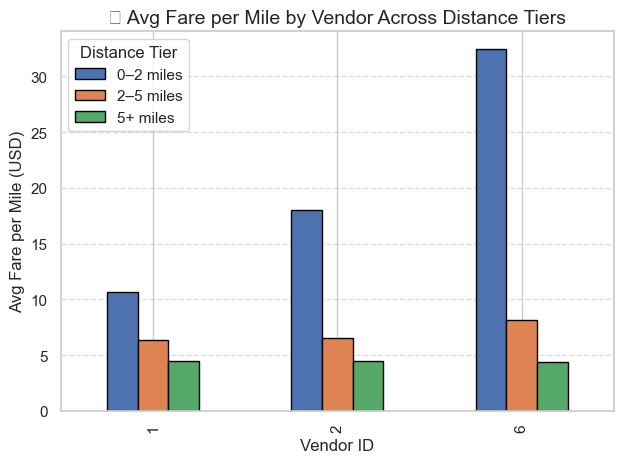

In [145]:
# Defining distance tiers

# Filter out invalid rows and calculate fare per mile
df_valid = df[(df['trip_distance'] > 0) & (df['fare_amount'] > 0)].copy()
df_valid['fare_per_mile'] = df_valid['fare_amount'] / df_valid['trip_distance']

# Define distance tiers
distance_bins = [0, 2, 5, np.inf]
distance_labels = ['0–2 miles', '2–5 miles', '5+ miles']
df_valid['distance_tier'] = pd.cut(df_valid['trip_distance'], bins=distance_bins, labels=distance_labels)

# Group by Vendor and Distance Tier, compute average fare per mile
avg_fare_by_tier = df_valid.groupby(['VendorID', 'distance_tier'])['fare_per_mile'].mean().unstack().round(2)

# Plot
plt.figure(figsize=(12, 6))
avg_fare_by_tier.plot(kind='bar', edgecolor='black')
plt.title("📊 Avg Fare per Mile by Vendor Across Distance Tiers", fontsize=14)
plt.xlabel("Vendor ID", fontsize=12)
plt.ylabel("Avg Fare per Mile (USD)", fontsize=12)
plt.legend(title='Distance Tier')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

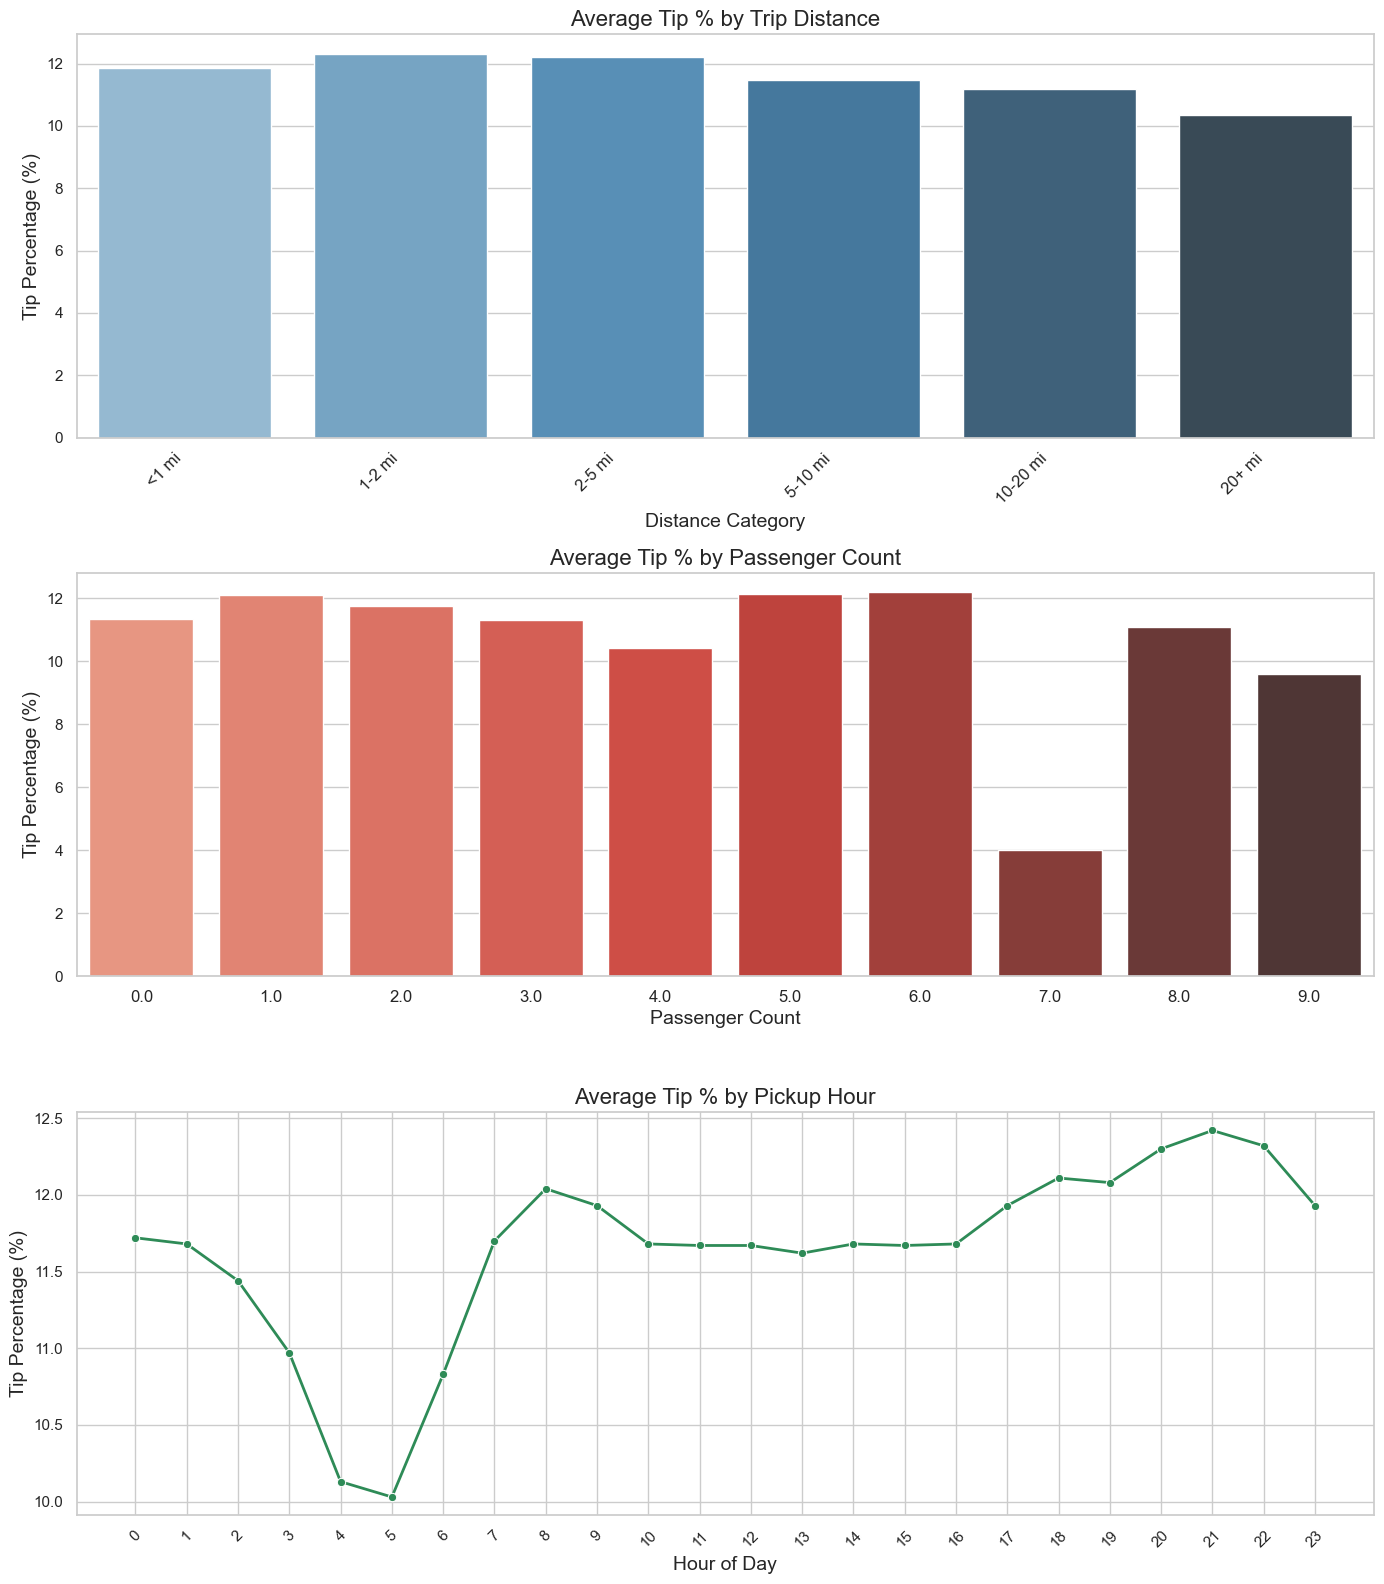

In [147]:
#  Analyze tip percentages based on distances, passenger counts and pickup times


# Set the Seaborn style for better aesthetics
sns.set(style="whitegrid", palette="muted")

# Filter valid rows (total_amount > 0, tip_amount >= 0)
df_tip = df[(df['total_amount'] > 0) & (df['tip_amount'] >= 0)].copy()

# Calculate Tip Percentage
df_tip['tip_pct'] = (df_tip['tip_amount'] / df_tip['total_amount']) * 100  # Tip percentage

# Bin distances into categories
distance_bins = [0, 1, 2, 5, 10, 20, np.inf]
distance_labels = ['<1 mi', '1-2 mi', '2-5 mi', '5-10 mi', '10-20 mi', '20+ mi']
df_tip['distance_bin'] = pd.cut(df_tip['trip_distance'], bins=distance_bins, labels=distance_labels)

# Group by distance bin and calculate average tip percentage
tip_by_distance = df_tip.groupby('distance_bin')['tip_pct'].mean().round(2)

# Group by passenger count and calculate average tip percentage
tip_by_passengers = df_tip.groupby('passenger_count')['tip_pct'].mean().round(2)

# Extract pickup hour and calculate average tip percentage by hour
df_tip['pickup_hour'] = pd.to_datetime(df_tip['tpep_pickup_datetime']).dt.hour
tip_by_hour = df_tip.groupby('pickup_hour')['tip_pct'].mean().round(2)

# Plotting: Create subplots with advanced visual styles
fig, axs = plt.subplots(3, 1, figsize=(14, 16))

# Plot Tip % by Distance
sns.barplot(x=tip_by_distance.index, y=tip_by_distance.values, ax=axs[0], palette="Blues_d")
axs[0].set_title('Average Tip % by Trip Distance', fontsize=16)
axs[0].set_ylabel('Tip Percentage (%)', fontsize=14)
axs[0].set_xlabel('Distance Category', fontsize=14)
axs[0].set_xticklabels(tip_by_distance.index, rotation=45, ha="right")
axs[0].tick_params(axis='x', labelsize=12)

# Plot Tip % by Passenger Count
sns.barplot(x=tip_by_passengers.index, y=tip_by_passengers.values, ax=axs[1], palette="Reds_d")
axs[1].set_title('Average Tip % by Passenger Count', fontsize=16)
axs[1].set_ylabel('Tip Percentage (%)', fontsize=14)
axs[1].set_xlabel('Passenger Count', fontsize=14)
axs[1].tick_params(axis='x', labelsize=12)

# Plot Tip % by Pickup Hour
sns.lineplot(x=tip_by_hour.index, y=tip_by_hour.values, ax=axs[2], color='seagreen', marker='o', linewidth=2)
axs[2].set_title('Average Tip % by Pickup Hour', fontsize=16)
axs[2].set_ylabel('Tip Percentage (%)', fontsize=14)
axs[2].set_xlabel('Hour of Day', fontsize=14)
axs[2].set_xticks(range(24))
axs[2].set_xticklabels(range(24), rotation=45)

# Customize layout for tight spacing and better readability
plt.tight_layout()
plt.show()


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [149]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
# Filter trips based on tip percentage
low_tip_df = df_tip[df_tip['tip_pct'] < 10]
high_tip_df = df_tip[df_tip['tip_pct'] > 25]

# Define the comparison metrics
comparison = {
    "Average Fare": [low_tip_df['fare_amount'].mean(), high_tip_df['fare_amount'].mean()],
    "Average Trip Distance": [low_tip_df['trip_distance'].mean(), high_tip_df['trip_distance'].mean()],
    "Average Tip %": [low_tip_df['tip_pct'].mean(), high_tip_df['tip_pct'].mean()],
    "Average Passengers": [low_tip_df['passenger_count'].mean(), high_tip_df['passenger_count'].mean()],
    "Most Common Pickup Hour": [
        low_tip_df['pickup_hour'].mode().iloc[0],
        high_tip_df['pickup_hour'].mode().iloc[0]
    ],
    "Most Common Day of Week": [
        low_tip_df['pickup_day'].mode().iloc[0],
        high_tip_df['pickup_day'].mode().iloc[0]
    ],
    "Most Common Vendor": [
        low_tip_df['VendorID'].mode().iloc[0],
        high_tip_df['VendorID'].mode().iloc[0]
    ]
}

# Create a DataFrame for comparison
comparison_df = pd.DataFrame(comparison, index=["Tip < 10%", "Tip > 25%"])

# Display the results
print(comparison_df)



           Average Fare  Average Trip Distance  Average Tip %  \
Tip < 10%         20.96                   4.03           2.38   
Tip > 25%         13.90                   2.21          36.03   

           Average Passengers  Most Common Pickup Hour  \
Tip < 10%                1.39                       18   
Tip > 25%                1.35                       14   

           Most Common Day of Week  Most Common Vendor  
Tip < 10%                        3                   2  
Tip > 25%                        5                   2  


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

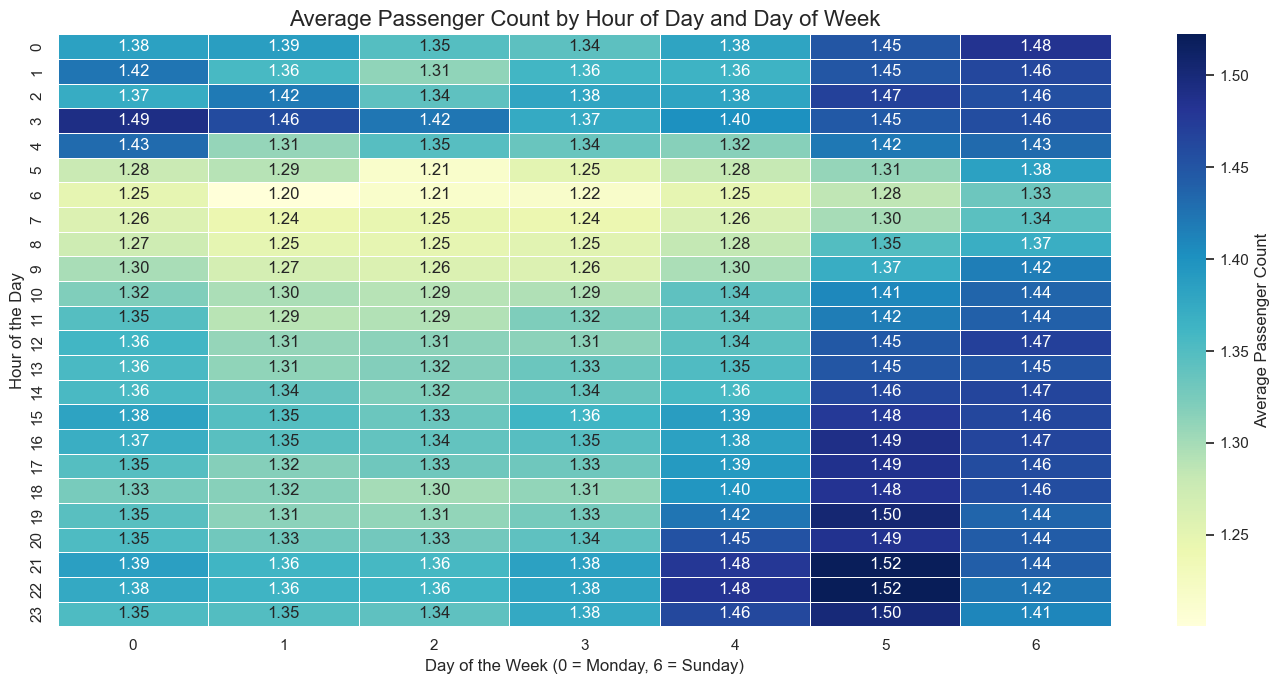

In [151]:
# See how passenger count varies across hours and days

# Group by pickup hour and day of week, then compute average passenger count
passenger_heatmap_data = df.groupby(['pickup_hour', 'pickup_day'])['passenger_count'].mean().unstack()

# Plotting the heatmap with enhanced formatting
plt.figure(figsize=(14, 7))  # Slightly larger for better readability
sns.heatmap(
    passenger_heatmap_data, 
    annot=True, 
    fmt=".2f",  # Format to 2 decimal places
    cmap="YlGnBu", 
    cbar_kws={'label': 'Average Passenger Count'},  # Add a color bar label
    linewidths=0.5,  # Adds spacing between the cells for better clarity
    linecolor='white'  # Lighter line color for better visibility
)

# Title and labels
plt.title("Average Passenger Count by Hour of Day and Day of Week", fontsize=16)
plt.xlabel("Day of the Week (0 = Monday, 6 = Sunday)", fontsize=12)
plt.ylabel("Hour of the Day", fontsize=12)

# Adjust layout and show plot
plt.tight_layout()
plt.show()


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

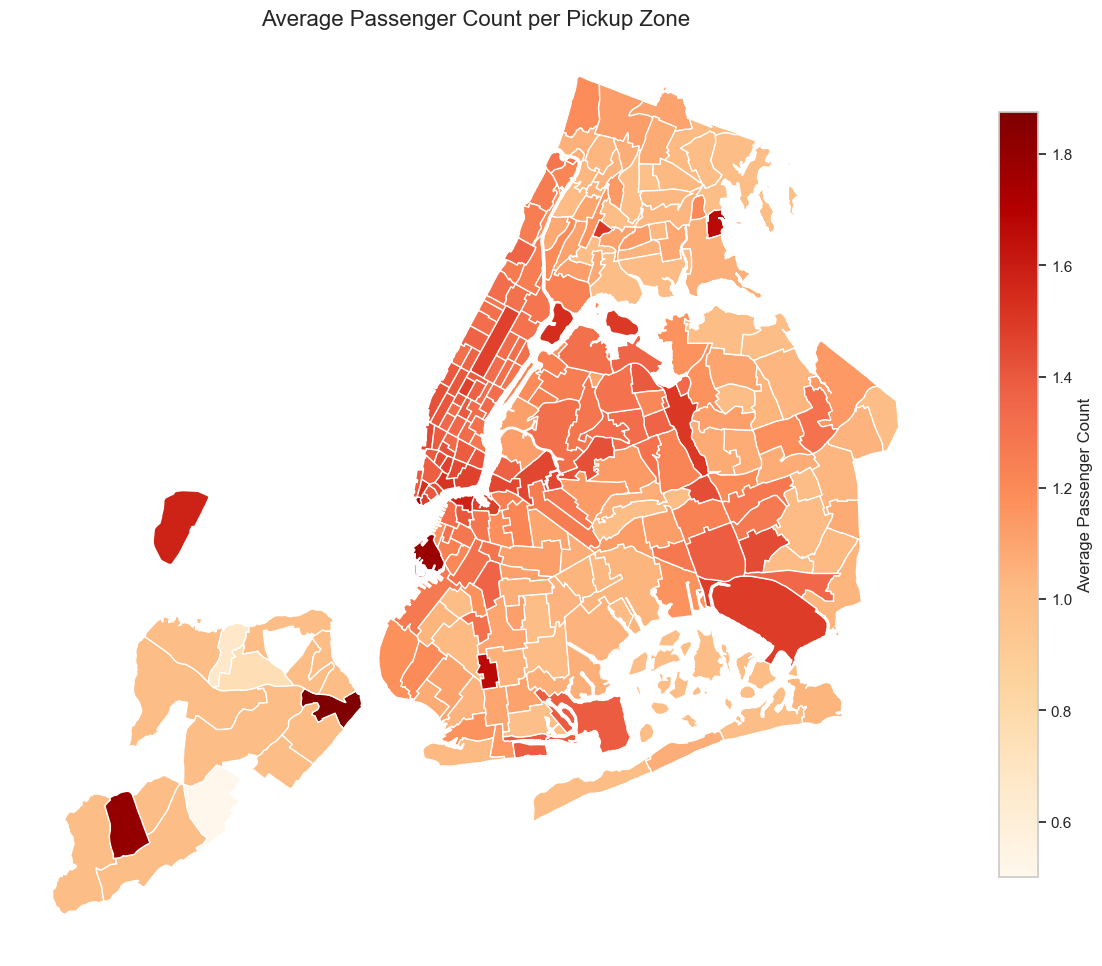

In [155]:
# How does passenger count vary across zones
# Calculate average passenger count by pickup zone
avg_passenger_by_zone = df.groupby('PULocationID')['passenger_count'].mean().reset_index()
avg_passenger_by_zone.columns = ['LocationID', 'avg_passenger_count']

# Merge with zones GeoDataFrame
zones_with_passenger_count = zones.merge(avg_passenger_by_zone, on='LocationID')

# Plotting the choropleth map with enhanced formatting
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the zones with average passenger count using a color map
zones_with_passenger_count.plot(
    column='avg_passenger_count', 
    ax=ax, 
    legend=True, 
    cmap='OrRd',  # Color map (Oranges to Red)
    legend_kwds={
        'label': "Average Passenger Count",  # Label for the color bar
        'orientation': "vertical",
        'shrink': 0.8,  # Shrink the color bar to fit better
        'aspect': 20  # Aspect ratio for the legend to make it more readable
    }
)

# Title and axis adjustments
plt.title("Average Passenger Count per Pickup Zone", fontsize=16)
plt.axis('off')  # Turn off the axis for better visual clarity

# Show the plot
plt.tight_layout()  # Ensures everything fits well in the figure
plt.show()


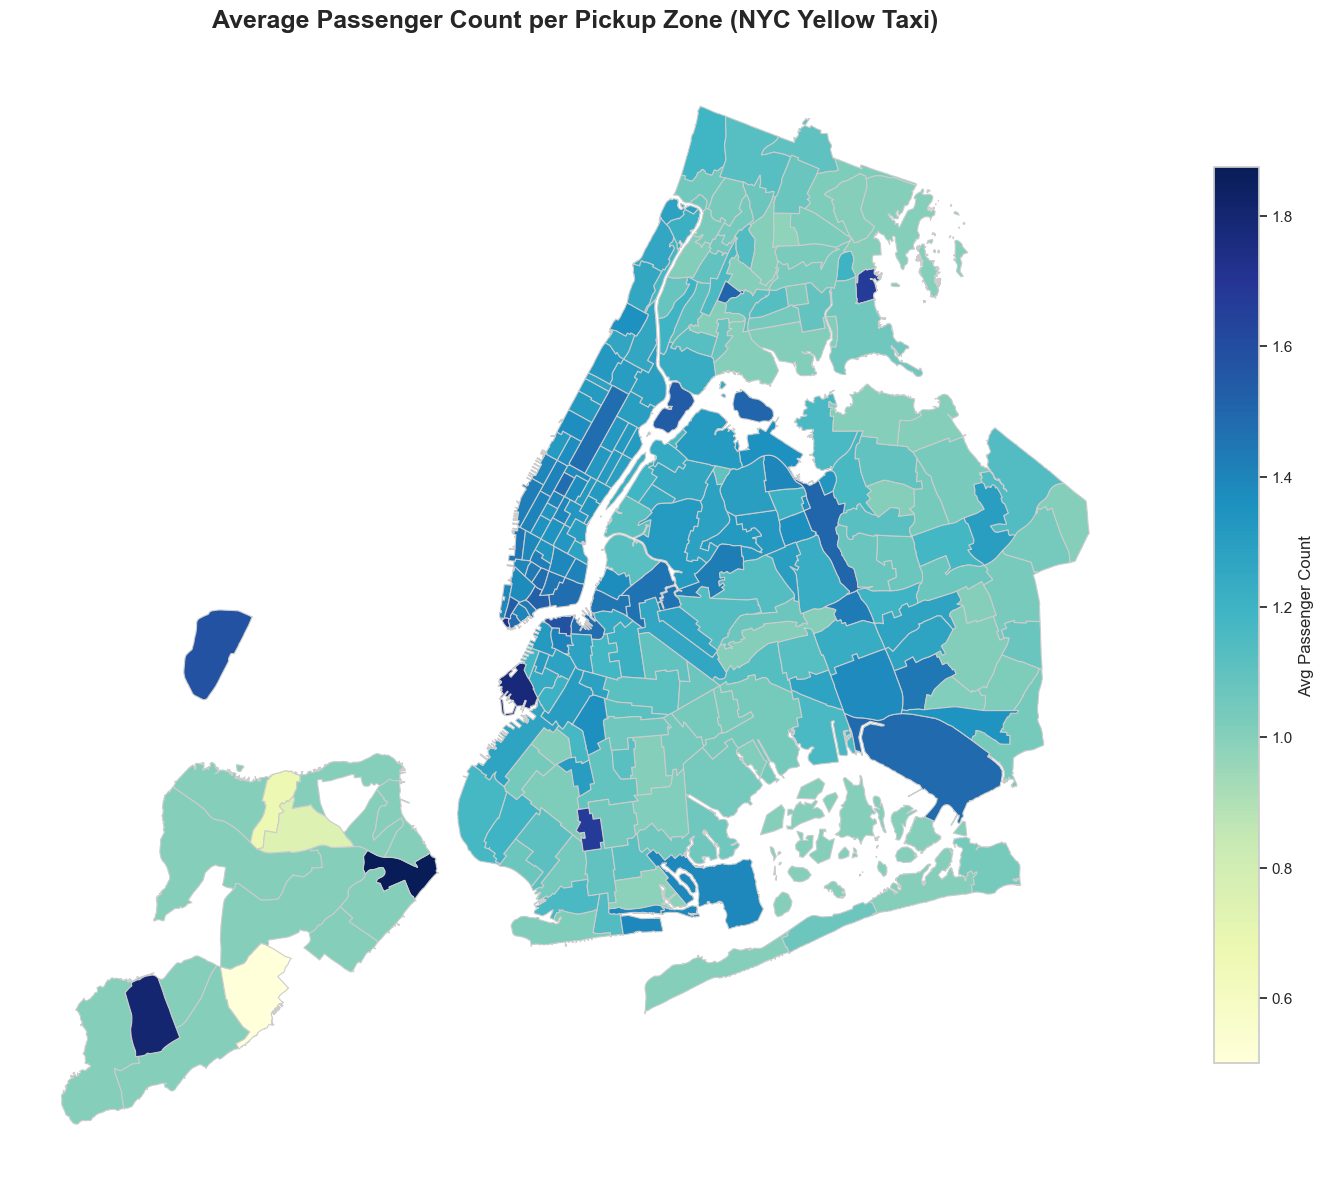

In [157]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

# Calculate the number of trips and average passenger count per zone
trips_by_zone = df.groupby('PULocationID').size().reset_index(name='num_trips')
avg_passenger_by_zone = df.groupby('PULocationID')['passenger_count'].mean().reset_index()
avg_passenger_by_zone.columns = ['PULocationID', 'avg_passenger_count']

# Merge the data for number of trips and average passenger count
zone_stats = pd.merge(trips_by_zone, avg_passenger_by_zone, on='PULocationID')
zone_stats.columns = ['LocationID', 'num_trips', 'avg_passenger_count']

# Ensure zones GeoDataFrame has a matching column name
zones = zones.rename(columns={'locationID': 'LocationID'})

# Merge the zone statistics with the zones GeoDataFrame
zones_with_trips = zones.merge(zone_stats, on='LocationID', how='left')

# Set up the plot
fig, ax = plt.subplots(1, 1, figsize=(15, 12))

# Plot zones colored by average passenger count
zones_with_trips.plot(
    column='avg_passenger_count',  # Column for color mapping
    cmap='YlGnBu',                 # Color palette (YlGnBu for more differentiation)
    legend=True,                   # Show legend
    linewidth=0.8,
    edgecolor='0.8',
    ax=ax,
    legend_kwds={'shrink': 0.8, 'orientation': 'vertical', 'label': 'Avg Passenger Count'}
)

# Title and aesthetic tweaks
ax.set_title('Average Passenger Count per Pickup Zone (NYC Yellow Taxi)', fontsize=18, fontweight='bold', pad=20)
ax.axis('off')  # Hide axis

# Show the plot
plt.tight_layout()
plt.show()


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

Extra charges distribution:
 extra
0.00     756816
2.50     466513
1.00     363923
5.00     134302
3.50     107345
7.50      16269
6.00      15523
4.25       6382
9.25       6351
1.75       3346
3.75       2616
6.75       2416
2.75       2218
8.75       2132
10.25      1692
7.75       1463
1.25       1418
11.75      1332
2.25        894
6.25        826
10.00       567
9.75        549
7.25        481
11.25       411
8.50        369
3.20         43
3.00         39
2.00         27
5.25         22
0.50         22
4.75         12
0.75         11
4.50          8
1.50          8
3.25          8
2.45          6
0.70          5
2.72          5
14.25         3
12.50         3
7.00          3
0.25          2
-1.00         2
3.05          2
6.80          2
-2.50         1
20.80         1
0.01          1
5.30          1
11.00         1
4.05          1
1.26          1
2.20          1
1.05          1
13.75         1
8.20          1
0.03          1
0.19          1
Name: count, dtype: int64

Congestion

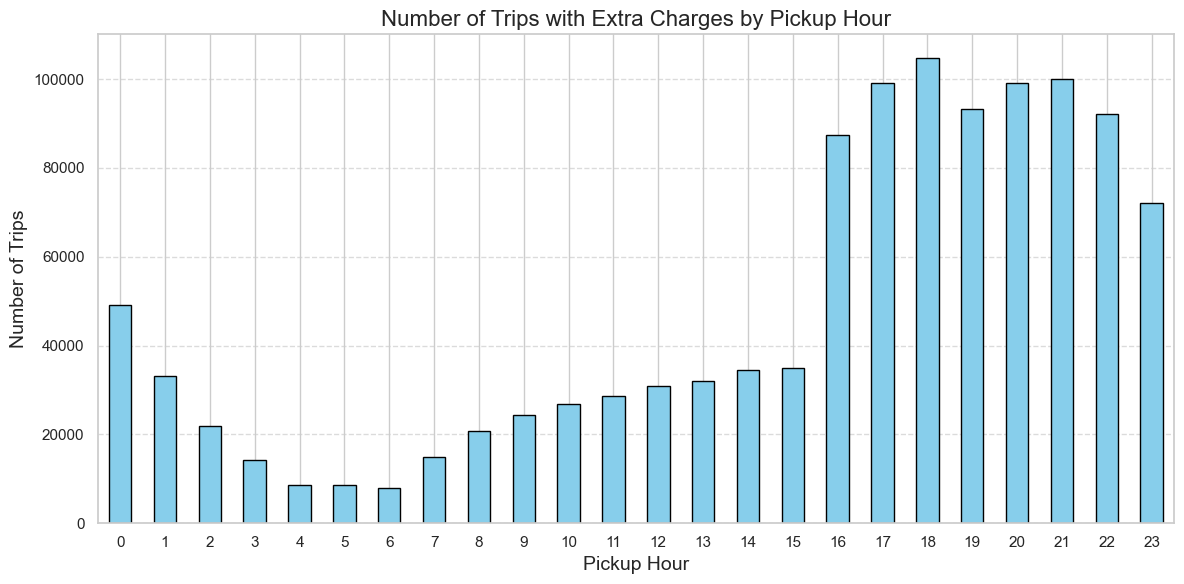


Top Pickup Zones with Extra Charges:
 PULocationID
138    63581
161    55486
237    50312
132    48047
236    41509
162    40966
230    40906
142    38683
186    37461
163    34296
Name: count, dtype: int64

Top Dropoff Zones with Extra Charges:
 DOLocationID
236    47601
237    43132
161    36518
230    33786
170    33535
239    32338
142    31618
141    31573
48     29728
162    28779
Name: count, dtype: int64


In [159]:
# How often is each surcharge applied?

# Analyzing how often each surcharge is applied

# Extra charges distribution
extra_counts = df['extra'].value_counts()
print("Extra charges distribution:\n", extra_counts)

# Congestion surcharge distribution
congestion_counts = df['congestion_surcharge'].value_counts()
print("\nCongestion surcharge distribution:\n", congestion_counts)

# Airport fee distribution
airport_counts = df['airport_fee'].value_counts()
print("\nAirport fee distribution:\n", airport_counts)

# Add pickup hour if not already available
if 'pickup_hour' not in df.columns:
    df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

# Analyze when extra charges are applied (i.e., when 'extra' > 0)
extra_by_hour = df[df['extra'] > 0]['pickup_hour'].value_counts().sort_index()

# Plotting number of trips with extra charges by pickup hour
plt.figure(figsize=(12, 6))
extra_by_hour.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Number of Trips with Extra Charges by Pickup Hour', fontsize=16)
plt.xlabel('Pickup Hour', fontsize=14)
plt.ylabel('Number of Trips', fontsize=14)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Top pickup zones with extra charges
pickup_zones_with_extra = df[df['extra'] > 0]['PULocationID'].value_counts().head(10)
print("\nTop Pickup Zones with Extra Charges:\n", pickup_zones_with_extra)

# Top dropoff zones with extra charges
dropoff_zones_with_extra = df[df['extra'] > 0]['DOLocationID'].value_counts().head(10)
print("\nTop Dropoff Zones with Extra Charges:\n", dropoff_zones_with_extra)


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

**Optimized Fleet Strategy**
Efficient Dispatching:
- Expand fleet availability between 4 to 6 AM to accommodate early airport travelers.
- Boost operations from 10 AM to 5 PM to meet midday demand.
- Deploy smaller vehicles for late-night trips in entertainment districts to enhance maneuverability and cost efficiency.

Weekend Focus:
- Strengthen Saturday and Sunday operations with extra shifts or surge pricing to match peak demand.

Strategic Zone Coverage:
- Concentrate fleet in East Village, West Village, and Lower East Side during nighttime hours.
- Maintain strong coverage at JFK Airport throughout the night and early morning.

Passenger Volume Optimization:
- Encourage shared rides through discounted rates in areas with a high number of solo travelers.

Night Shift Incentives:
- Provide bonuses to night drivers to leverage high'-'surcharge periods and enhance late-night service reliability.

Eliminating Inefficiencies:
- Minimize operations during low-demand periods (8 to 10 PM) unless targeting hotspots like Times Square.
- Prioritize high-revenue windows, focusing on 4-6 AM and 3-5 PM, when demand surges.

This refined approach optimizes scheduling, reduces inefficiencies, and maximizes revenue potential while ensuring smooth fleet operations. 

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

In [ ]:
print(zones.columns)  # Check column names in the zones GeoDataFrame
print(pickup_zone_totals.columns)  # Check column names in the pickup counts DataFrame

PULocationID
132    97047
237    88610
161    87590
236    79756
162    66712
138    64449
186    64318
230    62672
142    62664
170    55933
Name: trip_count, dtype: int64
PULocationID
132    27835
79     20128
237    18351
161    17520
142    17131
186    16770
230    16591
236    16519
48     16353
249    16261
Name: trip_count, dtype: int64
PULocationID
1     2186.82
216    314.88
134    268.55
265    245.94
197    207.83
190    116.77
207    111.19
28      94.00
47      84.11
258     83.60
Name: fare_per_mile, dtype: float64
     PULocationID time_of_day  fare_amount
237           132         day   4774860.22
249           138         day   2416355.55
238           132       night   1279207.08
294           161         day   1277072.90
436           237         day   1060691.48
..            ...         ...          ...
218           122       night        15.20
197           111         day        14.20
107            58       night        12.80
452           245       night    

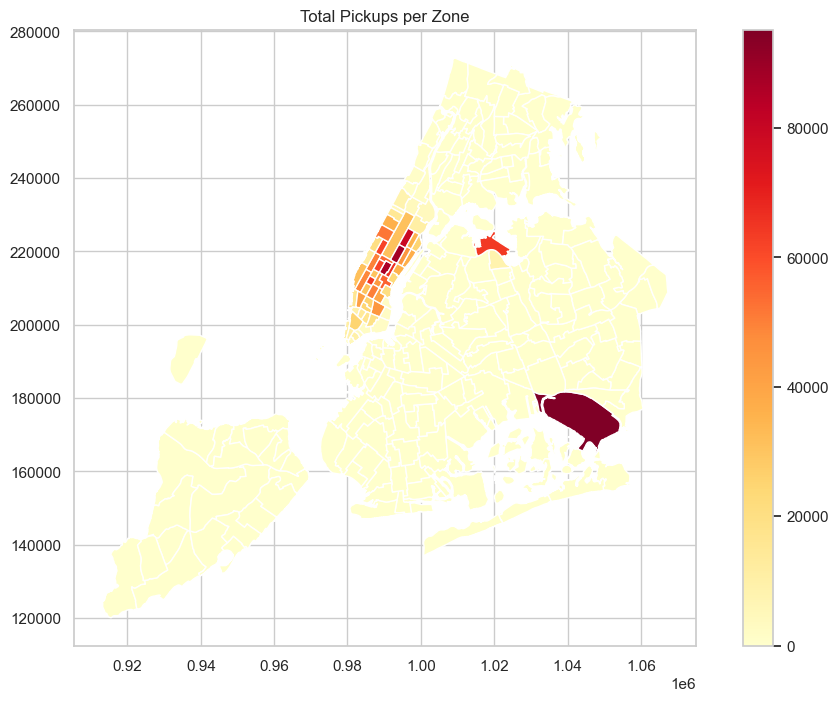

In [186]:
# Group pickups by zone and hour
pickup_by_zone_hour = df.groupby([df['PULocationID'], df['pickup_datetime'].dt.hour]) \
    .size().reset_index(name='trip_count')

# Pivot table for easy viewing of pickups by zone and hour
pickup_pivot = pickup_by_zone_hour.pivot(index='PULocationID', 
                                         columns='pickup_datetime', 
                                         values='trip_count').fillna(0)

# View the top 10 zones with the highest total pickups
pickup_totals = pickup_by_zone_hour.groupby('PULocationID')['trip_count'].sum() \
    .sort_values(ascending=False).head(10)
print(pickup_totals)

# Add 'pickup_dayofweek' column for analysis
df['pickup_dayofweek'] = df['pickup_datetime'].dt.dayofweek  # Monday = 0, Sunday = 6

# Group by zone and day of week
pickup_by_zone_day = df.groupby(['PULocationID', 'pickup_dayofweek']).size().reset_index(name='trip_count')

# Pivot table for pickups by zone and day of week
pickup_day_pivot = pickup_by_zone_day.pivot(index='PULocationID', 
                                            columns='pickup_dayofweek', 
                                            values='trip_count').fillna(0)

# View busiest zones during the weekend (Saturday and Sunday)
weekend_zones = pickup_by_zone_day[pickup_by_zone_day['pickup_dayofweek'].isin([5, 6])]
weekend_totals = weekend_zones.groupby('PULocationID')['trip_count'].sum() \
    .sort_values(ascending=False).head(10)
print(weekend_totals)

# Calculate fare per mile and clean any invalid entries
df['fare_per_mile'] = df['fare_amount'] / df['trip_distance']
df = df[df['fare_per_mile'].replace([np.inf, -np.inf], np.nan).notnull()]

# Group fare per mile by zone and sort in descending order
fare_by_zone = df.groupby('PULocationID')['fare_per_mile'].mean().sort_values(ascending=False)
print(fare_by_zone.head(10))

# Define function to classify time of day
def time_of_day(hour):
    return 'night' if hour < 6 or hour >= 22 else 'day'

df['time_of_day'] = df['pickup_datetime'].dt.hour.apply(time_of_day)

# Group revenue by zone and time of day
revenue_by_zone_time = df.groupby(['PULocationID', 'time_of_day'])['fare_amount'].sum().reset_index()
print(revenue_by_zone_time.sort_values(by='fare_amount', ascending=False))

# Merge pickup totals with zone information
pickup_zone_totals = df.groupby('PULocationID').size().reset_index(name='trip_count')
zones_with_pickups = zones.merge(pickup_zone_totals, left_on='LocationID', 
                                 right_on='PULocationID', how='left').fillna(0)

# Plot total pickups per zone on a map
zones_with_pickups.plot(column='trip_count', cmap='YlOrRd', legend=True, figsize=(12, 8))
plt.title('Total Pickups per Zone')
plt.show()


   PULocationID  trip_count  LocationID                          zone
0           132       95193         132                   JFK Airport
1           237       87921         237         Upper East Side South
2           161       86637         161                Midtown Center
3           236       78957         236         Upper East Side North
4           162       66099         162                  Midtown East
5           138       63962         138             LaGuardia Airport
6           186       63669         186  Penn Station/Madison Sq West
7           142       61880         142           Lincoln Square East
8           230       61761         230     Times Sq/Theatre District
9           170       55150         170                   Murray Hill
   PULocationID  trip_count  LocationID                          zone
0           132       27299         132                   JFK Airport
1            79       19641          79                  East Village
2           237     

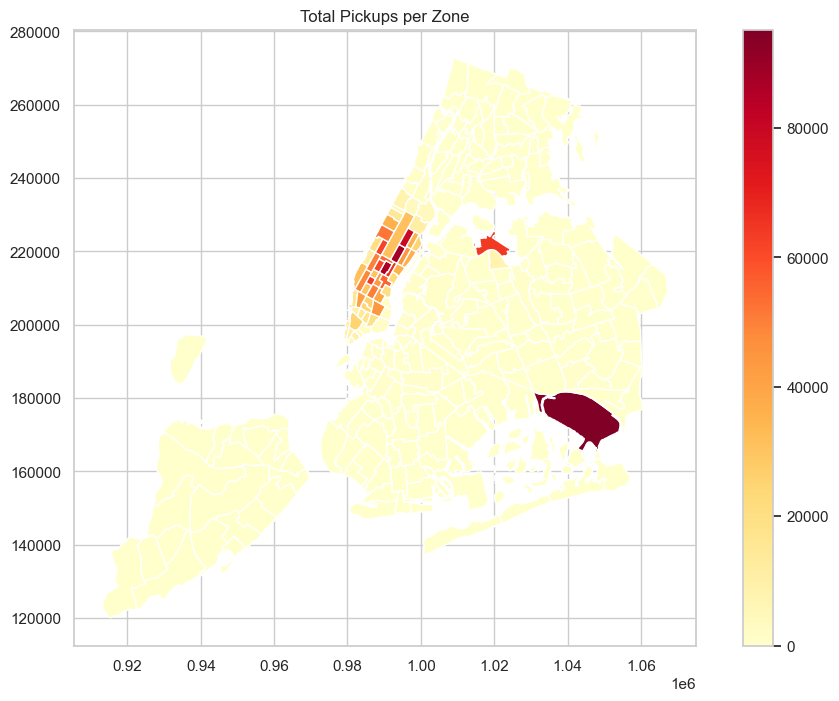

In [200]:
# Group pickups by zone and hour
pickup_by_zone_hour = df.groupby([df['PULocationID'], df['pickup_datetime'].dt.hour]) \
    .size().reset_index(name='trip_count')

# Pivot table for easy viewing of pickups by zone and hour
pickup_pivot = pickup_by_zone_hour.pivot(index='PULocationID', 
                                         columns='pickup_datetime', 
                                         values='trip_count').fillna(0)

# View the top 10 zones with the highest total pickups
pickup_totals = pickup_by_zone_hour.groupby('PULocationID')['trip_count'].sum() \
    .sort_values(ascending=False).head(10)

# Reset the index to avoid ambiguity in merge
pickup_totals_reset = pickup_totals.reset_index()

# Merge with zones to get the zone names
pickup_totals_with_names = pickup_totals_reset.merge(zones[['LocationID', 'zone']], 
                                                     left_on='PULocationID', 
                                                     right_on='LocationID', 
                                                     how='left')
print(pickup_totals_with_names)

# Add 'pickup_dayofweek' column for analysis
df['pickup_dayofweek'] = df['pickup_datetime'].dt.dayofweek  # Monday = 0, Sunday = 6

# Group by zone and day of week
pickup_by_zone_day = df.groupby(['PULocationID', 'pickup_dayofweek']).size().reset_index(name='trip_count')

# Pivot table for pickups by zone and day of week
pickup_day_pivot = pickup_by_zone_day.pivot(index='PULocationID', 
                                            columns='pickup_dayofweek', 
                                            values='trip_count').fillna(0)

# View busiest zones during the weekend (Saturday and Sunday)
weekend_zones = pickup_by_zone_day[pickup_by_zone_day['pickup_dayofweek'].isin([5, 6])]
weekend_totals = weekend_zones.groupby('PULocationID')['trip_count'].sum() \
    .sort_values(ascending=False).head(10)

# Reset index to avoid ambiguity and merge with zone names
weekend_totals_reset = weekend_totals.reset_index()
weekend_totals_with_names = weekend_totals_reset.merge(zones[['LocationID', 'zone']], 
                                                       left_on='PULocationID', 
                                                       right_on='LocationID', 
                                                       how='left')
print(weekend_totals_with_names)

# Calculate fare per mile and clean any invalid entries
df['fare_per_mile'] = df['fare_amount'] / df['trip_distance']
df = df[df['fare_per_mile'].replace([np.inf, -np.inf], np.nan).notnull()]

# Group fare per mile by zone and sort in descending order
fare_by_zone = df.groupby('PULocationID')['fare_per_mile'].mean().sort_values(ascending=False)

# Reset index to avoid ambiguity and merge with zone names
fare_by_zone_reset = fare_by_zone.reset_index()
fare_by_zone_with_names = fare_by_zone_reset.merge(zones[['LocationID', 'zone']], 
                                                   left_on='PULocationID', 
                                                   right_on='LocationID', 
                                                   how='left')
print(fare_by_zone_with_names.head(10))

# Define function to classify time of day
def time_of_day(hour):
    return 'night' if hour < 6 or hour >= 22 else 'day'

df['time_of_day'] = df['pickup_datetime'].dt.hour.apply(time_of_day)

# Group revenue by zone and time of day
revenue_by_zone_time = df.groupby(['PULocationID', 'time_of_day'])['fare_amount'].sum().reset_index()

# Merge with zones to get the zone names
revenue_by_zone_time_with_names = revenue_by_zone_time.merge(zones[['LocationID', 'zone']], 
                                                             left_on='PULocationID', 
                                                             right_on='LocationID', 
                                                             how='left')
print(revenue_by_zone_time_with_names.sort_values(by='fare_amount', ascending=False))

# Merge pickup totals with zone information
pickup_zone_totals = df.groupby('PULocationID').size().reset_index(name='trip_count')
zones_with_pickups = zones.merge(pickup_zone_totals, left_on='LocationID', right_on='PULocationID', how='left').fillna(0)

# Plot total pickups per zone on a map with zone names
zones_with_pickups = zones_with_pickups.merge(zones[['LocationID', 'zone']], left_on='LocationID', right_on='LocationID', how='left')
zones_with_pickups.plot(column='trip_count', cmap='YlOrRd', legend=True, figsize=(12, 8))
plt.title('Total Pickups per Zone')
plt.show()


**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

To maximize revenue while staying competitive, consider these adjustments:

1. **Dynamic Pricing**: Increase prices during peak times (e.g., early morning for airports, midday) and lower rates during off-peak hours (late night or early morning).
   
2. **Zone-Based Pricing**: Apply premium rates for high-demand zones (e.g., **JFK Airport**, **Midtown Center**) and discounts for less busy areas like **Clinton East** and **West Village**.

3. **Time-of-Day Adjustments**: Set different fares for day and night, with higher rates during the night for airport and high-surcharge zones.

4. **Incentives**: Offer bonuses for drivers working during night shifts and discounts for frequent travelers.

5. **Fare Optimization**: Adjust fares based on distance and fare per mile analysis, keeping long trips slightly higher in price.

6. **Weekend Strategy**: Prioritize weekend operations with surge pricing for busy areas like **Times Square** and **JFK Airport**.

7. **Real-time Monitoring**: Keep an eye on competitor prices and adjust accordingly to stay competitive while maximizing revenue.